# Uplift Modeling em Marketing — Notebook 3: Meta-learners (S/T/X/R)

> Continuação de `02_Baseline_Propensity_PT.ipynb`. Este notebook não compartilha o
> kernel do anterior — recarrega abaixo os splits de treino/validação e o baseline de
> propensão de S3.2 (cujo score entra na tabela comparativa de S4.3). O teste selado
> continua oculto: este notebook nunca o toca.

---

## Índice

- [Setup — retomando de S1-S3](#setup)
- [Seção 4 — Meta-learners (S/T/X/R)](#s4)
    - [4.1 Ajuste dos quatro meta-learners](#s4-1)
    - [4.2 Distribuição do CATE estimado por learner](#s4-2)
    - [4.3 Avaliação preliminar com métricas de uplift (validação)](#s4-3)
    - [4.4 Diagnóstico de heterogeneidade: sinal real ou ruído de amostragem?](#s4-4)
        - [4.4.1 Chão de ruído por permutação](#s4-4-1)
        - [4.4.2 GATES-lite: o ranking de CATE separa grupos com ATE diferente?](#s4-4-2)
    - [4.5 Iteração de features e regularização (X/R-learner)](#s4-5)
    - [4.6 Sensibilidade ao algoritmo base](#s4-6)
    - [4.7 Ablation: propensão conhecida vs. estimada internamente (X/R)](#s4-7)
    - [4.8 Isolando bagging: árvore única vs. Random Forest, mesma profundidade](#s4-8)
    - [4.9 Robustez sob reamostragem repetida](#s4-9)
        - [4.9.1 Estabilidade de `max_depth` (3/4/5)](#s4-9-1)
        - [4.9.2 Comparação pareada: o líder contra concorrentes fortes já vistos](#s4-9-2)
        - [4.9.3 Os dois líderes contra o baseline de propensão](#s4-9-3)
        - [4.9.4 Por que o Qini AUC varia tanto entre amostras?](#s4-9-4)
    - [4.10 S-learner linear com interações T×X explícitas (opcional, baseline interpretável)](#s4-10)
    - [Síntese da Seção 4](#s4-summary)
- [Glossário (referência rápida)](#glossary)

---

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning

# Bootstrap de path: permite `from src...` a partir de notebooks/
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import SEED
from src.i18n import make_lang
from src.viz import apply_plot_style

np.random.seed(SEED)
pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 4)
warnings.filterwarnings('ignore', category=FutureWarning)
# Modelo de propensão interno dos meta-learners do causalml (S4) usa um
# solver elastic-net que não converge dentro do max_iter padrão em bases
# pequenas — não afeta o resultado (é só o nuisance model), mas polui a saída.
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Idioma canônico deste notebook é PT — passthrough, sem chamada de rede.
# A edição EN (futura) troca só esta linha para make_lang('en').
lang = make_lang('pt')

apply_plot_style()

In [2]:
# Stack causal (verifique a instalação antes da primeira run)
# pip install econml causalml scikit-uplift shap mlflow

# Meta-learners e árvores de uplift
from causalml.inference.meta import BaseSRegressor, BaseTRegressor, BaseXRegressor, BaseRRegressor
from causalml.inference.tree import UpliftRandomForestClassifier

# Causal Forest com intervalos de confiança
from econml.dml import CausalForestDML
from econml.metalearners import TLearner, SLearner, XLearner

# Avaliação
from sklift.metrics import uplift_at_k, qini_auc_score, uplift_auc_score

from src.compat import patch_sklearn_matplotlib_support
patch_sklearn_matplotlib_support()
from sklift.viz import plot_qini_curve, plot_uplift_curve

# Interpretabilidade
import shap

Failed to import duecredit due to No module named 'duecredit'


In [3]:
from src.config import ARTIFACTS_DIR, RETRAIN

ARTIFACTS_DIR.mkdir(exist_ok=True, parents=True)

# MLflow — ajuste o URI conforme seu setup Windows
# mlflow.set_tracking_uri('file:///C:/path/to/mlruns')
# mlflow.set_experiment('uplift_hillstrom')

<a id="setup"></a>

## Setup — retomando de S1-S3

No fluxo normal, `get_train_val` carrega os manifests de treino/validação já persistidos
por `02_Baseline_Propensity_PT` (`train_index.parquet`, `validation_index.parquet`,
`dataset_manifest.json`) e valida o fingerprint SHA-256 e `n_rows` do dataset atual contra
o manifest — sem reescrever o índice do teste selado, que só o notebook 2 grava. Recalcular
via `train_test_split` é só o fallback de bootstrap, usado quando nenhum split ainda foi
persistido; uma vez que um teste selado existe, esse fallback nunca acontece silenciosamente
(ver `src/splits.py`). Também reajustamos o baseline de propensão de S3.2, barato o
suficiente para não valer a pena serializar.

In [4]:
from src.config import POOLED_TREATMENT_COL, PRIMARY_OUTCOME
from src.data import add_pooled_treatment, load_hillstrom
from src.learners import fit_propensity_baseline, predict_propensity_score
from src.splits import get_train_val

df = load_hillstrom()
df_pooled = add_pooled_treatment(df)
train_df, val_df = get_train_val(df_pooled, persist_test=False)

propensity_model = fit_propensity_baseline(train_df, POOLED_TREATMENT_COL, PRIMARY_OUTCOME)
val_df['propensity_score'] = predict_propensity_score(propensity_model, val_df)

labels = lang({'header': 'Tamanho das partições (retomado de S3)'})
print(f"{labels['header']}:")
print(f"  Treino:     {len(train_df):>6} linhas | tratados: {int(train_df[POOLED_TREATMENT_COL].sum()):>6}")
print(f"  Validação:  {len(val_df):>6} linhas | tratados: {int(val_df[POOLED_TREATMENT_COL].sum()):>6}")

Tamanho das partições (retomado de S3):
  Treino:      38400 linhas | tratados:  25617
  Validação:   12800 linhas | tratados:   8538


<a id='s4'></a>
<a id="s4"></a>

# Seção 4 — Meta-learners (S/T/X/R)


O primeiro objetivo aqui será estimar CATE com os quatro meta-learners clássicos — S-, T-, X- e R-learner — usando **um único base learner (LightGBM)** para todos. Variar meta-learner e base learner ao mesmo tempo tornaria a comparação ininterpretável: se um vencer, não saberíamos se foi a estratégia de meta-aprendizado ou a capacidade do modelo de base.

O próximo passo será o outcome binário (`visit`) é tratado via variantes **Regressor** (regressão da probabilidade) nos quatro learners — não Classifier. Motivo: o R-learner do `causalml` só existe como Regressor; usar Classifier nos outros três criaria uma assimetria de capacidade entre learners, o que custa mais caro à comparação do que vale o ganho de usar a variante mais "correta" para classificação em três deles.

E então, produzir CATE out-of-sample na validação para os quatro, comparar com o baseline de propensão (S3) pelas mesmas métricas de uplift, e visualizar a forma da distribuição de cada estimador.

**Tratamento:** continua pooled (S3–S6), como estabelecido em S3.

> ### Hipótese registrada antes de rodar
> O **X-learner tem vantagem estrutural** neste dataset, porque foi desenhado especificamente para braços de tratamento desbalanceados — e aqui o pooled é 2:1 (tratados vs. controle). A verificação honesta dessa hipótese, com números reais, vem na Seção 4.3. Se não se sustentar, é isso que será reportado (Regra Absoluta #6: resultado negativo é resultado).


**Nota adicionada após o resultado de 4.3.** Nenhum meta-learner bateu o baseline com folga — isso levantou a pergunta de saber se o efeito de tratamento é próximo de homogêneo nesta população, ou se os estimadores (LightGBM vanilla, features brutas) não estavam capturando heterogeneidade real. Três subseções foram adicionadas para investigar, nesta ordem: **4.4** (diagnóstico: sinal real ou ruído?), **4.5** (features derivadas e regularização, focadas em X/R) e **4.6** (sensibilidade ao algoritmo base). Nenhuma delas reabre ou reajusta o que já foi decidido em 4.1-4.3 — todas comparam contra os resultados originais, lado a lado.

<a id='s4-1'></a>
<a id="s4-1"></a>

## 4.1 Ajuste dos quatro meta-learners

As categóricas (`zip_code`, `channel`, `history_segment`) precisam de um tratamento diferente do usado no baseline de S3: o `causalml` converte `X` para array numpy puro internamente antes de repassar ao learner de base, o que descarta o dtype `category` do pandas de que o LightGBM depende para lidar nativamente com categóricas. Por isso, aqui elas são codificadas via one-hot (ajustado só no treino) antes de entrar nos quatro meta-learners.

Segue o padrão `RETRAIN` do projeto: como é a primeira vez que estes modelos são ajustados, esta célula treina e serializa em `artifacts/meta_learners.joblib` mesmo com `RETRAIN=False` (comportamento de bootstrap, para não travar a primeira execução); reexecuções futuras carregam o artefato salvo em vez de retreinar, a menos que `RETRAIN=True`.

In [5]:
from src.config import META_LEARNERS_PATH
from src.learners import get_meta_learners, predict_meta_learners_uplift

meta_models, meta_encoder = get_meta_learners(
    train_df, POOLED_TREATMENT_COL, PRIMARY_OUTCOME, RETRAIN, META_LEARNERS_PATH,
)
meta_cate = predict_meta_learners_uplift(meta_models, val_df, meta_encoder)
for name, cate in meta_cate.items():
    val_df[f'{name.lower()}_learner_uplift'] = cate

labels = lang({'header': 'CATE estimado — resumo por learner (validação)'})
print(f"{labels['header']}:")
print(val_df[[f'{n.lower()}_learner_uplift' for n in meta_cate]].describe().T)

CATE estimado — resumo por learner (validação):
                    count    mean     std     min     25%     50%     75%  \
s_learner_uplift  12800.0  0.0584  0.0359 -0.1465  0.0360  0.0565  0.0777   
t_learner_uplift  12800.0  0.0593  0.0705 -0.3488  0.0257  0.0595  0.0945   
x_learner_uplift  12800.0  0.0596  0.0500 -0.2958  0.0350  0.0618  0.0877   
r_learner_uplift  12800.0  0.0591  0.0661 -0.4755  0.0326  0.0612  0.0890   

                     max  
s_learner_uplift  0.4188  
t_learner_uplift  0.4787  
x_learner_uplift  0.3537  
r_learner_uplift  0.4391  


<a id='s4-2'></a>
<a id="s4-2"></a>

## 4.2 Distribuição do CATE estimado por learner

Antes de comparar métricas, vale ver a forma da distribuição de cada estimador — meta-learners têm vieses conhecidos de viés/variância (S-learner tende a encolher efeitos quando o tratamento é só mais uma feature entre muitas; T-learner tende a ter mais variância por ajustar dois modelos totalmente independentes).

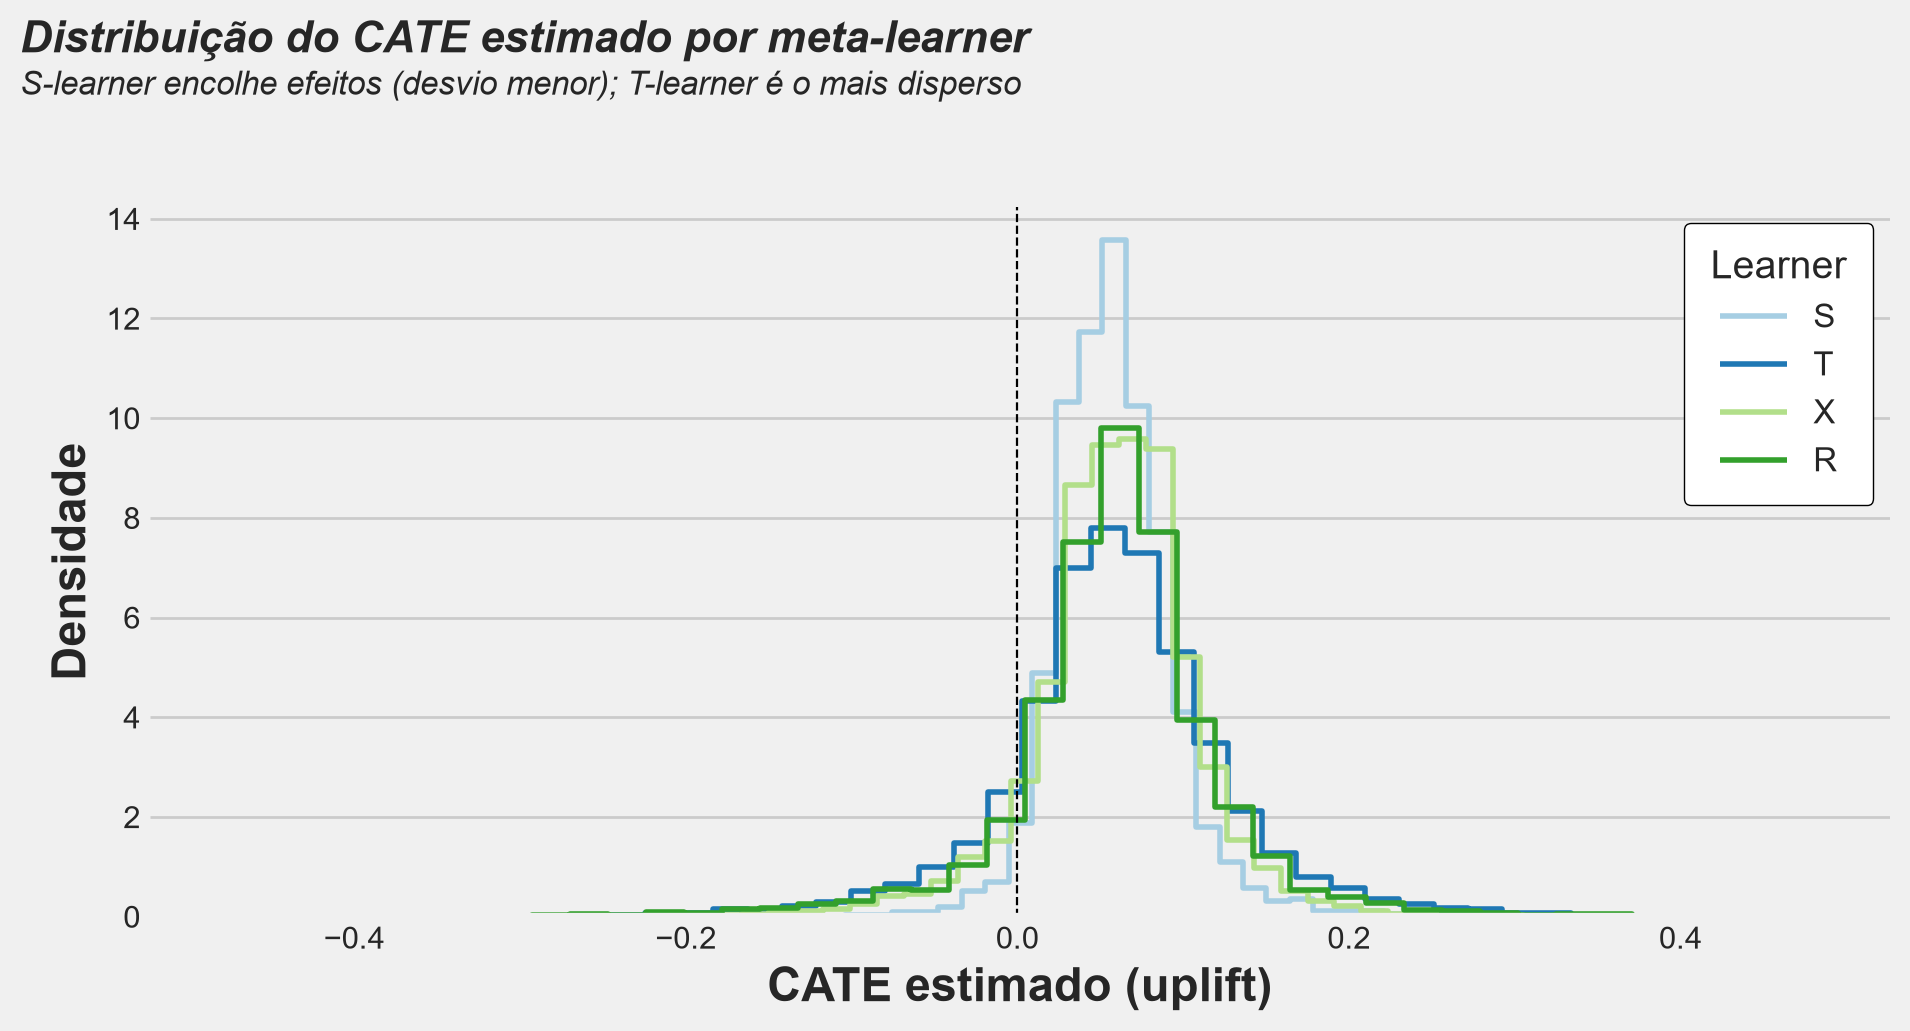

In [6]:
from src.viz import plot_uplift_distributions

labels = lang({
    'title': 'Distribuição do CATE estimado por meta-learner',
    'subtitle': 'S-learner encolhe efeitos (desvio menor); T-learner é o mais disperso',
})
fig, ax = plot_uplift_distributions(meta_cate, title=labels['title'], subtitle=labels['subtitle'])
plt.show()

>**Insights:** As quatro distribuições têm média muito próxima (0.058–0.060), consistente com o ATE pooled de ~6pp estimado em S2 — CATE deve, em média, recuperar o ATE. O que diferencia os quatro é a **dispersão**: o S-learner é visivelmente o mais concentrado >(desvio-padrão 0.036, faixa -0.15 a +0.42), exatamente o comportamento esperado de um estimador que compartilha um único modelo entre os braços e tende a encolher heterogeneidade. O T-learner é o mais disperso (desvio-padrão 0.070, faixa -0.35 a +0.48) — dois modelos totalmente independentes acumulam mais ruído na diferença. X- e R-learner ficam entre os dois extremos (desvio-padrão 0.050 e 0.066, respectivamente).

<a id='s4-3'></a>
<a id="s4-3"></a>

## 4.3 Avaliação preliminar com métricas de uplift (validação)

Mesma régua de S3.3 — Qini AUC, uplift AUC (AUUC) e uplift@30% — agora incluindo os quatro meta-learners ao lado do baseline de propensão. Ainda não é a comparação formal de S6 (sem bootstrap de IC, sem abrir o teste selado): é uma primeira leitura para orientar o que investigar em S5–S6. O T-learner rápido de S3.4 não entra aqui, como já declarado — era só uma checagem provisória.

In [7]:
from src.evaluation import evaluate_multiple_rankings

all_scores = {
    'Baseline (propensão)': val_df['propensity_score'],
    'S-learner': meta_cate['S'],
    'T-learner': meta_cate['T'],
    'X-learner': meta_cate['X'],
    'R-learner': meta_cate['R'],
}
comparison_table = evaluate_multiple_rankings(
    val_df[PRIMARY_OUTCOME].values, all_scores, val_df[POOLED_TREATMENT_COL].values,
)
print(comparison_table.round(4))

                      qini_auc  uplift_auc  uplift_at_30pct
Baseline (propensão)    0.0395      0.0235           0.0923
S-learner               0.0415      0.0244           0.0907
T-learner               0.0067      0.0042           0.0661
X-learner               0.0243      0.0145           0.0773
R-learner               0.0196      0.0113           0.0716


>**Insights:** 
>
>**A hipótese do X-learner não se sustentou.** Nenhum dos quatro meta-learners bate o baseline de propensão com folga clara nesta validação.
>
>**S-learner.** Qini AUC 0.0415 supera o baseline (0.0395) por uma margem mínima — na terceira casa decimal, pequena demais para sustentar uma escolha de modelo baseada apenas neste holdout único; a estabilidade desse resultado é investigada mais adiante, nos dados de desenvolvimento (4.9).
>
>**X-learner.** Qini AUC 0.0243 fica **abaixo** do baseline, contrariando a hipótese registrada em S4 de vantagem estrutural sob braços desbalanceados. Reportado como está: a hipótese não se sustentou.
>
>**T-learner.** Qini AUC 0.0067 é o pior dos quatro, por uma margem grande o bastante (quase 6x menor que o baseline) para não ser só ruído de terceira casa decimal — mesmo sem intervalo de confiança formal ainda.
>
>**R-learner.** Qini AUC 0.0196 fica no meio, também abaixo do baseline.
>
>Uma explicação plausível — não comprovada aqui, mas consistente com a literatura de meta-learners (Künzel et al., 2019) — é que X- e R-learner herdam ruído dos modelos de primeiro estágio: o X-learner constrói seus pseudo-efeitos a partir das mesmas regressões de outcome que fazem o T-learner performar mal isoladamente (ver `BaseXRegressor.fit` no `causalml`: `d_c`/`d_t` são calculados a partir das predições de `mu_c`/`mu_t`). O S-learner, ao usar um único modelo compartilhado entre os braços, tem menos variância para herdar — e isso, aparentemente, pesa mais do que a heterogeneidade que ele pode estar encolhendo.
>
>Nenhum ajuste de protocolo foi feito para produzir um vencedor diferente (Regra Absoluta #6). A estabilidade dos candidatos será investigada ainda nos dados de desenvolvimento; S6 ficará reservada à avaliação confirmatória da configuração final, já selecionada e congelada ao término de S5.

<a id='s4-4'></a>
<a id="s4-4"></a>

## 4.4 Diagnóstico de heterogeneidade: sinal real ou ruído de amostragem?

Nenhum meta-learner bateu o baseline com folga (S4.3) — isso pode significar duas coisas bem diferentes: (a) o efeito de tratamento é próximo de homogêneo nesta população (tratar quem já tem maior propensão natural já captura a maior parte do uplift), ou (b) os rankings estimados contêm estrutura associada a diferenças de efeito, embora os diagnósticos abaixo não constituam um teste formal de heterogeneidade contra um ATE homogêneo não nulo. As duas seções abaixo são dois diagnósticos complementares, não testes independentes — usam os mesmos dados e investigam aspectos relacionados da mesma estrutura, dentro de treino/validação; o teste selado não é tocado aqui.

> #### Regra de interpretação registrada antes de rodar — posteriormente qualificada
> A regra operacional inicialmente registrada era: se o desvio-padrão real de pelo menos um learner exceder o percentil 95 do chão de ruído por permutação (4.4.1), interpretar isso como evidência de heterogeneidade acima de ruído amostral. Após inspecionar precisamente o null gerado pela permutação, essa leitura foi qualificada: o procedimento testa um mundo em que τ(x)=0 para todo x, destruindo também o ATE — portanto, exceder esse chão indica estrutura além do null totalmente nulo, mas não constitui, por si só, evidência formal de heterogeneidade contra H0: τ(x)=ATE (efeito homogêneo não nulo). Caso o desvio real não exceda o percentil 95 em nenhum learner, a leitura original permanece: evidência a favor de efeito homogêneo (ou não capturável com os dados/features atuais) — declarada como limitação, sem forçar conclusão.

<a id="s4-4-1"></a>

### 4.4.1 Chão de ruído por permutação

Embaralhamos `treatment` no treino (quebrando de propósito qualquer associação real entre tratamento e outcome — não só a heterogeneidade, o ATE também), reajustamos **só o S-learner** (o mais barato dos quatro) e medimos `std(CATE)` na validação real. Repetimos 20 vezes — a distribuição resultante é o que se observaria de dispersão de CATE **sob um null totalmente sem associação tratamento-outcome** (H0: τ(x)=0 para todo x), só ruído de amostragem e overfitting do modelo. Comparamos essa distribuição contra a dispersão real de cada learner, já medida em 4.2.

**O que este teste não é:** por embaralhar o tratamento, o null destrói o ATE junto com a heterogeneidade — não é um teste formal de heterogeneidade contra um efeito homogêneo não nulo (H0: τ(x)=ATE), que exigiria preservar o ATE e perturbar só a dependência em X. Tratamos isso explicitamente como diagnóstico exploratório, não como teste de heterogeneidade propriamente dito.

Escopo: testamos só o S-learner por custo — é uma decisão explícita, não um atalho silencioso. T/X/R têm dispersão real ainda maior que a do S-learner; se o S-learner já supera seu próprio chão de ruído, é plausível (não comprovado aqui) que os outros três também superem o deles.

In [8]:
from src.evaluation import permutation_noise_floor

permuted_stds = permutation_noise_floor(
    train_df, val_df, POOLED_TREATMENT_COL, PRIMARY_OUTCOME, meta_encoder,
    learner_name='S', n_reps=20,
)
real_stds = {name: float(cate.std()) for name, cate in meta_cate.items()}

labels = lang({'header': 'Chão de ruído por permutação (S-learner, 20 repetições)'})
print(f"{labels['header']}:")
print(f"  min={permuted_stds.min():.4f}  p50={pd.Series(permuted_stds).median():.4f}  "
    f"p95={pd.Series(permuted_stds).quantile(0.95):.4f}  max={permuted_stds.max():.4f}")
print(f"\nDesvios reais por learner: {({k: round(v, 4) for k, v in real_stds.items()})}")

Chão de ruído por permutação (S-learner, 20 repetições):
  min=0.0166  p50=0.0229  p95=0.0273  max=0.0290

Desvios reais por learner: {'S': 0.0359, 'T': 0.0705, 'X': 0.05, 'R': 0.0661}


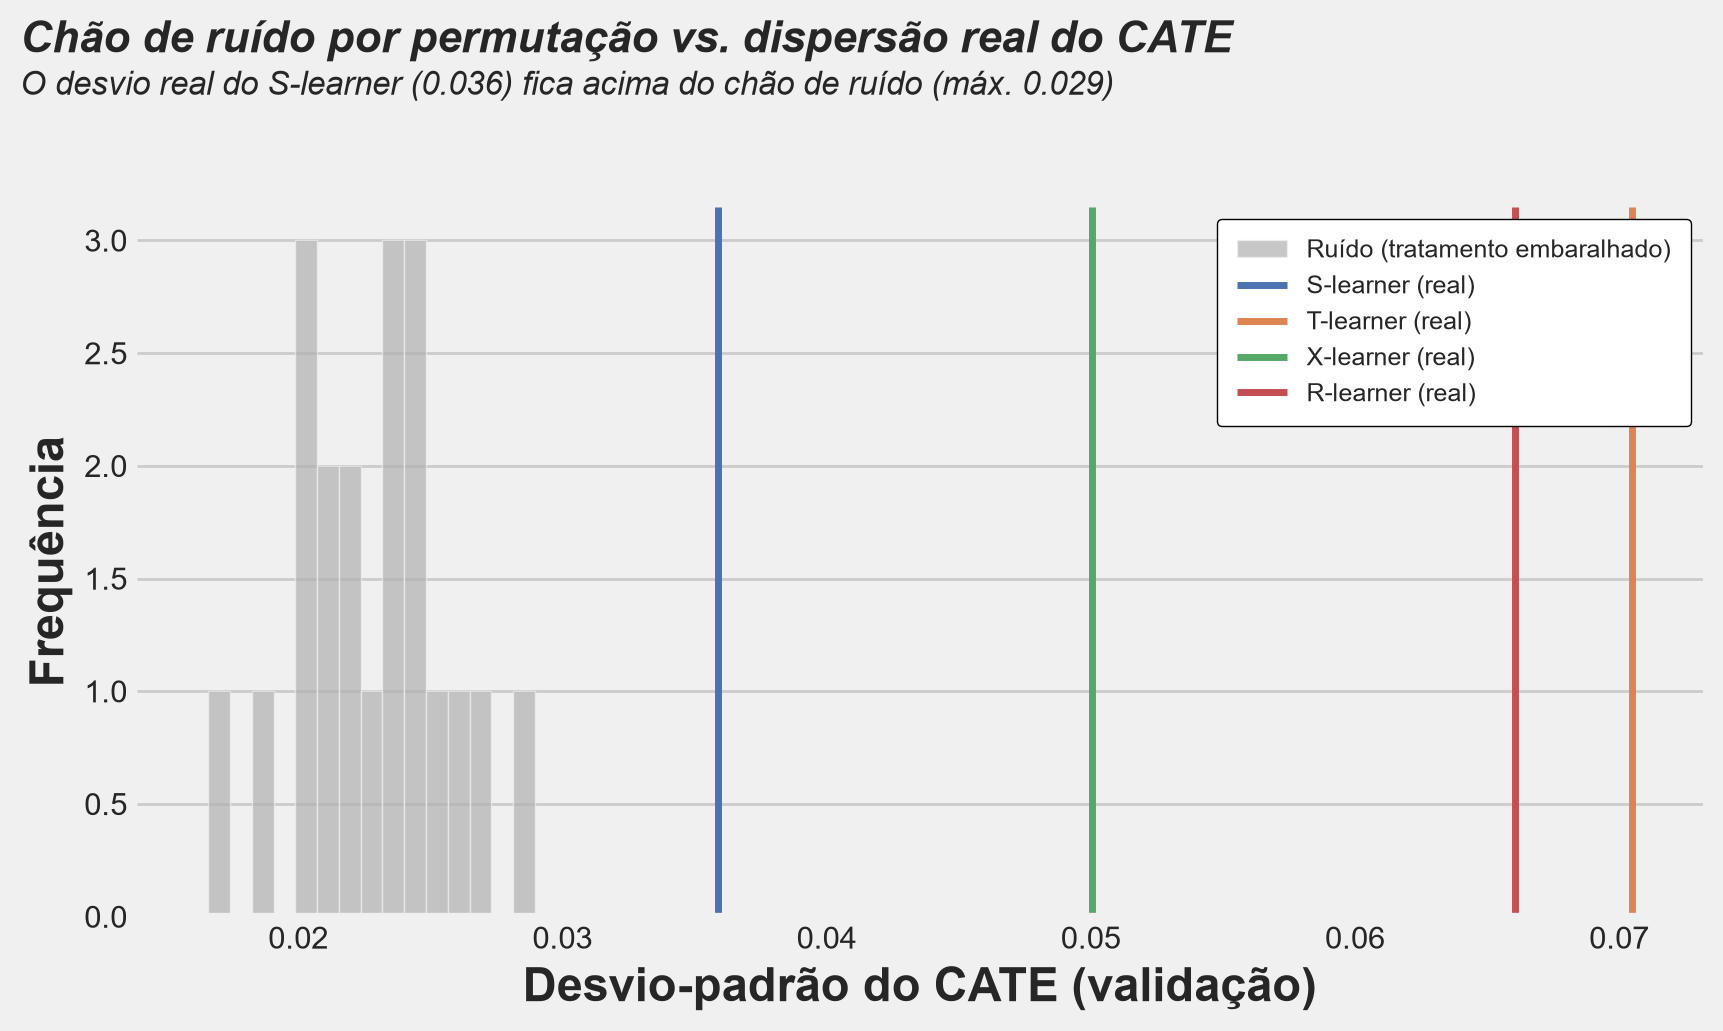

In [9]:
from src.viz import plot_permutation_noise_floor

labels = lang({
    'title': 'Chão de ruído por permutação vs. dispersão real do CATE',
    'subtitle': 'O desvio real do S-learner (0.036) fica acima do chão de ruído (máx. 0.029)',
})
fig, ax = plot_permutation_noise_floor(permuted_stds, real_stds, title=labels['title'], subtitle=labels['subtitle'])
plt.show()

>**Insights:** 
>
>O chão de ruído por permutação (S-learner, 20 repetições) vai de 0.0166 a 0.0290 (p95 = 0.0273, média 0.0228) — essa é a dispersão de CATE que o próprio S-learner produziria sob um null que destrói integralmente a associação tratamento-outcome (não só a heterogeneidade — o ATE também), só por ruído de amostragem. O desvio-padrão real do S-learner (0.0359, medido em 4.2) fica **acima do máximo observado no chão de ruído**, e bem acima do percentil 95 (0.0273).
>
>**A dispersão do CATE observado excede aquela produzida sob um null que destrói integralmente a associação tratamento–outcome, sugerindo estrutura além de ruído puro. Esse diagnóstico não constitui, porém, um teste formal de heterogeneidade contra um efeito de tratamento homogêneo não nulo** — permutar o tratamento zera o ATE junto com qualquer heterogeneidade, então superar este chão de ruído é consistente tanto com "há heterogeneidade real" quanto com "o ATE é não nulo e o modelo captura algum ruído de estimação diferente sob ATE≠0 vs. ATE=0" sem que isso implique τ(x) variando de fato por X. Não distinguimos essas duas hipóteses aqui.
>
>Os outros três learners têm dispersão real ainda maior (T=0.0705, X=0.0500, R=0.0661) — não testamos o chão de ruído deles individualmente (custo), mas como todos superam a dispersão real do S-learner, é plausível que também superem seus respectivos chãos de ruído. Isso não foi verificado diretamente aqui, e não tratamos essa extrapolação como conclusão — é só um indício.
>
>**Isso qualifica, mas não resolve, a leitura de S4.3.** O resultado fraco de Qini AUC não pode ser tomado como confirmação de efeito homogêneo só com base neste teste — há estrutura acima de ruído puro sendo capturada, mas se essa estrutura é heterogeneidade genuína (τ(x) variando por X) ou reflexo de um ATE não nulo com ruído de estimação assimétrico, este diagnóstico não decide. Um teste que preserve o ATE e isole só a dependência em X ficaria para trabalho futuro (não implementado nesta rodada). Essa distinção motiva tentar features melhores e regularização (S4.5) antes de descartar os meta-learners — não porque a heterogeneidade esteja confirmada, mas porque o resultado atual não permite descartá-la.

<a id="s4-4-2"></a>

### 4.4.2 GATES-lite: o ranking de CATE separa grupos com ATE diferente?

Grouped Average Treatment Effects (Chernozhukov et al., 2018), simplificado: ranqueamos a validação pelo CATE estimado de cada learner, cortamos em quintis, e estimamos o ATE **dentro de cada quintil** (via `effects.ate_binary`, a mesma função de S2.5), com IC de 95%. Se o quintil de maior CATE previsto tem ATE real maior e distinguível do quintil de menor CATE previsto (ICs não sobrepostos), o ranking carrega sinal útil de heterogeneidade — mesmo que a métrica de Qini agregada não mostre vantagem clara sobre o baseline.

In [10]:
from src.evaluation import gates_by_cate_quintile

gates_tables = {
    name: gates_by_cate_quintile(val_df, f'{name.lower()}_learner_uplift', PRIMARY_OUTCOME, POOLED_TREATMENT_COL)
    for name in meta_cate
}
for name, gates_df in gates_tables.items():
    print(f"\n{name}-learner:")
    print(gates_df.round(4))


S-learner:
   group     n  cate_mean     ate      se  ci_low  ci_high  p_value
0      0  2560     0.0142  0.0493  0.0145  0.0208   0.0778   0.0007
1      1  2560     0.0398  0.0470  0.0132  0.0210   0.0729   0.0004
2      2  2560     0.0564  0.0357  0.0136  0.0090   0.0624   0.0089
3      3  2560     0.0729  0.0661  0.0136  0.0394   0.0928   0.0000
4      4  2560     0.1085  0.1050  0.0143  0.0770   0.1329   0.0000

T-learner:
   group     n  cate_mean     ate      se  ci_low  ci_high  p_value
0      0  2560    -0.0351  0.0624  0.0149  0.0332   0.0916   0.0000
1      1  2560     0.0324  0.0577  0.0129  0.0325   0.0830   0.0000
2      2  2560     0.0594  0.0412  0.0134  0.0149   0.0674   0.0021
3      3  2560     0.0871  0.0624  0.0134  0.0361   0.0887   0.0000
4      4  2560     0.1527  0.0793  0.0147  0.0506   0.1081   0.0000

X-learner:
   group     n  cate_mean     ate      se  ci_low  ci_high  p_value
0      0  2560    -0.0099  0.0495  0.0148  0.0204   0.0785   0.0008
1      1  25

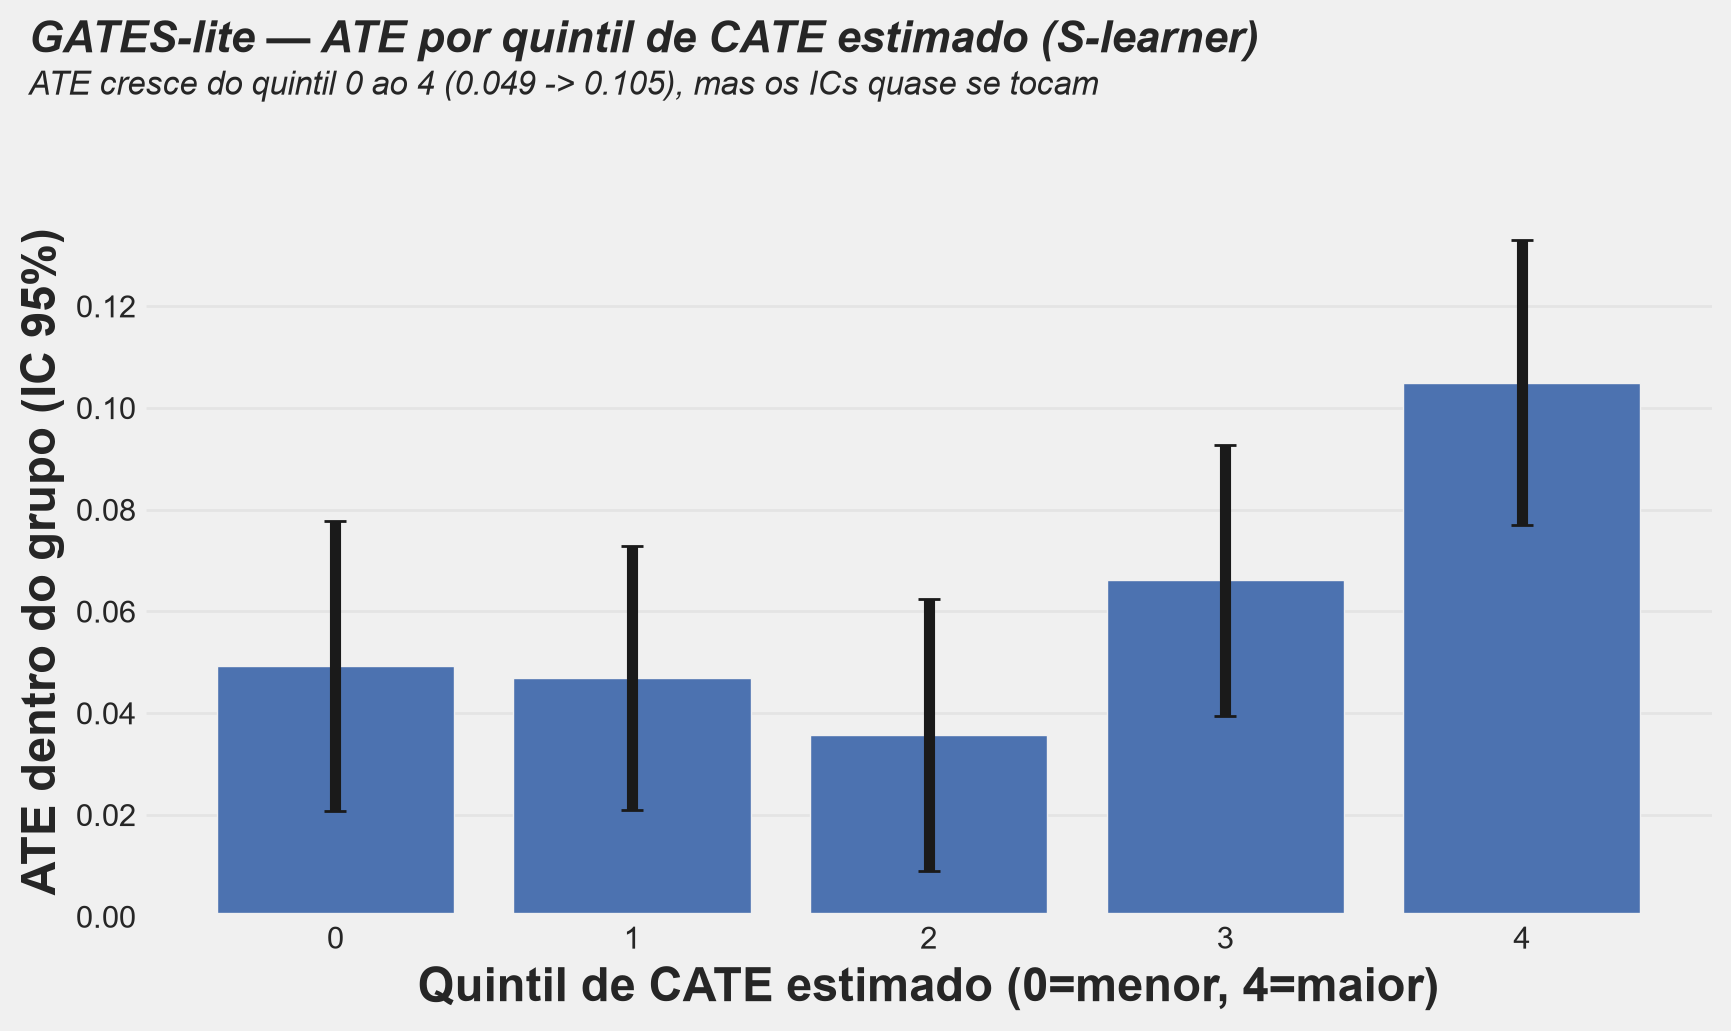

In [11]:
from src.viz import plot_gates_bars

labels = lang({
    'title': 'GATES-lite — ATE por quintil de CATE estimado (S-learner)',
    'subtitle': 'ATE cresce do quintil 0 ao 4 (0.049 -> 0.105), mas os ICs quase se tocam',
})
fig, ax = plot_gates_bars(gates_tables['S'], title=labels['title'], subtitle=labels['subtitle'])
plt.show()

>**Insights:** 
>
>Nos quatro learners, o ATE dentro do quintil de maior CATE previsto (grupo 4) é o mais alto entre os cinco grupos, e a tendência entre os grupos é aproximadamente crescente. O padrão é sugestivo de que os rankings carregam alguma informação sobre diferenças de efeito, embora os learners sejam avaliados sobre os mesmos indivíduos e seus rankings sejam correlacionados — não quatro confirmações independentes (a ressalva completa está na leitura de `gates_delta_bootstrap`, logo abaixo). No S-learner, por exemplo, o ATE vai de 0.049 (grupo 0) a 0.105 (grupo 4).
>
>Mas pelo critério estrito de não sobreposição de IC, a evidência é **limítrofe, não conclusiva**: no S-learner, o IC do grupo 0 é [0.021, 0.078] e o do grupo 4 é [0.077, 0.133] — os intervalos quase não se tocam (sobrepõem por uma fatia de 0.0008), um caso de fronteira. Nos outros três learners (T, X, R) a sobreposição entre o grupo 0 e o grupo 4 é maior, não permitindo declarar "distinguível" com confiança. Com ~2.560 linhas por quintil e uma taxa de visita de base modesta, o poder estatístico para separar quintis é limitado — isso é uma limitação dos dados, não um defeito do método.
>
>Conclui-se que os dois diagnósticos apontam na mesma direção, mas nenhum dos dois é um teste formal de heterogeneidade: 4.4.1 mostra que a dispersão real do CATE excede o chão de ruído de um null que destrói toda a associação tratamento-outcome (não distingue heterogeneidade de um ATE homogêneo não nulo — ver ressalva na célula acima), e 4.4.2 mostra um padrão de ATE crescente por quintil de CATE nos quatro learners, mas limítrofe por IC estrito. Juntos, são indícios consistentes de que **algo além de ruído puro está presente e o ranking por CATE parece carregar algum sinal**, sem que isso confirme heterogeneidade genuína (τ(x) variando por X) de forma conclusiva. Isso qualifica a pergunta original: o resultado fraco de Qini AUC de S4.3 não pode ser lido como confirmação de efeito homogêneo, mas também não temos evidência formal do contrário — o que motiva testar features melhores e regularização (S4.5) e sensibilidade ao algoritmo base (S4.6) antes de descartar os meta-learners, tratando a questão de heterogeneidade real vs. ATE homogêneo como uma limitação em aberto, não resolvida nesta seção.

In [12]:
from scipy.stats import spearmanr

from src.evaluation import gates_delta_bootstrap

gates_delta_results = {}
for name in meta_cate:
    col = f'{name.lower()}_learner_uplift'
    result = gates_delta_bootstrap(val_df, col, PRIMARY_OUTCOME, POOLED_TREATMENT_COL, n_groups=5, n_boot=2000)
    rho, rho_p = spearmanr(gates_tables[name]['group'], gates_tables[name]['ate'])
    result['spearman_rho'] = rho
    result['spearman_p'] = rho_p
    gates_delta_results[name] = result

labels = lang({'header': 'Δ_GATES = ATE(quintil topo) − ATE(quintil base), IC 95% via bootstrap (n_boot=2000)'})
print(f"{labels['header']}:\n")
for name, r in gates_delta_results.items():
    print(f"{name}-learner: Δ_GATES={r['delta_gates']:.4f}  IC95%=[{r['ci_low']:.4f}, {r['ci_high']:.4f}]  "
          f"p={r['p_value']:.4f}  |  tendência monótona: rho={r['spearman_rho']:.3f} p={r['spearman_p']:.4f}")

Δ_GATES = ATE(quintil topo) − ATE(quintil base), IC 95% via bootstrap (n_boot=2000):

S-learner: Δ_GATES=0.0557  IC95%=[0.0153, 0.0950]  p=0.0080  |  tendência monótona: rho=0.600 p=0.2848
T-learner: Δ_GATES=0.0170  IC95%=[-0.0247, 0.0597]  p=0.4110  |  tendência monótona: rho=0.600 p=0.2848
X-learner: Δ_GATES=0.0434  IC95%=[0.0052, 0.0835]  p=0.0250  |  tendência monótona: rho=0.400 p=0.5046
R-learner: Δ_GATES=0.0263  IC95%=[-0.0143, 0.0691]  p=0.2170  |  tendência monótona: rho=0.900 p=0.0374


>**Insights:** 
>
>**Δ_GATES direto confirma sinal em 2 dos 4 learners, mas não trate isso como 4 evidências independentes.** Em vez de só checar se os ICs de topo/base "quase se tocam" (teste indireto, usado acima), `gates_delta_bootstrap` estima a distribuição de Δ_GATES = ATE(quintil 4) − ATE(quintil 0) diretamente, via bootstrap dentro de cada quintil (apropriado ao desenho randomizado — re-amostrar linhas preserva a mecânica de atribuição aleatória dentro de cada estrato fixo):
>
>| Learner | Δ_GATES | IC 95% | p-valor | Tendência monótona (Spearman, quintil × ATE) |
>|---|---|---|---|---|
>| S | **0.0557** | [0.0153, 0.0950] | **0.0080** | ρ=0.600, p=0.2848 |
>| T | 0.0170 | [-0.0247, 0.0597] | 0.4110 | ρ=0.600, p=0.2848 |
>| X | **0.0434** | [0.0052, 0.0835] | **0.0250** | ρ=0.400, p=0.5046 |
>| R | 0.0263 | [-0.0143, 0.0691] | 0.2170 | ρ=0.900, p=0.0374 |
>
>Para S e X, o IC exclui zero — o quintil de maior CATE previsto tem ATE real distinguível do quintil de menor CATE previsto, um resultado mais direto (e melhor powered) do que a checagem informal de sobreposição de IC feita acima. Para T e R, o IC inclui zero — não há evidência direta de separação entre topo e base nesses dois. A tendência monótona (Spearman entre índice do quintil e ATE do quintil) tem poder muito baixo com só 5 pontos por learner — nenhuma passa de sugestiva, e a única com p<0.05 (R, ρ=0.900) é justamente o learner cujo Δ_GATES não é significativo, ilustrando que "tendência monótona" e "extremos distinguíveis" são leituras diferentes do mesmo GATES, não redundantes.
>
>**Isso não são quatro peças independentes de evidência.** Os quatro learners são avaliados nos mesmos ~12.800 indivíduos de `val_df`, e seus rankings de CATE são correlacionados entre si (todos usam as mesmas 8 covariáveis e o mesmo outcome) — um sinal real detectado por um learner tende a aparecer, com força variável, nos outros também, precisamente porque não são amostras independentes. Ver 2 de 4 resultados significativos não deve ser lido como "50% dos modelos confirmam heterogeneidade" no sentido estatístico de testes independentes — é mais correto dizer que há um único sinal subjacente nos dados, capturado com força desigual por diferentes learners, e que a evidência mais direta desse sinal vem do S- e do X-learner especificamente.
>
>Isso é consistente com a leitura qualificada de 4.4.1: há estrutura além de ruído puro (agora com uma segunda confirmação, mais direta, para S e X), mas isso ainda não é um teste formal de heterogeneidade τ(x) variando por X contra um ATE homogêneo não nulo — ambos os diagnósticos desta seção são compatíveis com essa distinção continuar em aberto.
>
>**Uma ressalva sobre o que este IC cobre.** O bootstrap de `gates_delta_bootstrap` reamostra linhas *dentro* dos quintis de topo e de base já definidos pelo ranking de CATE observado — os grupos ficam fixos, só as linhas dentro de cada grupo são reamostradas. Isso mede a incerteza do contraste Δ_GATES para esses grupos específicos, mas não incorpora a incerteza adicional que existiria se, em cada réplica de bootstrap, o próprio learner fosse reajustado e os indivíduos fossem novamente ranqueados e realocados aos quintis — essa segunda fonte de incerteza (do pipeline de estimação de CATE, não só da estimação do ATE dentro de grupos fixos) não está capturada aqui. Isso é aceitável para o papel de diagnóstico GATES-lite desta seção, mas o IC acima não deve ser lido como inferência completa sobre todo o pipeline de estimação de CATE.

<a id='s4-5'></a>
<a id="s4-5"></a>

## 4.5 Iteração de features e regularização (X/R-learner)

X- e R-learner ficaram abaixo do baseline em 4.3 (0.0243 e 0.0196 vs. 0.0395). Os diagnósticos de 4.4 mostraram estrutura acima do null de ruído puro e sinal sugestivo nos rankings, sem confirmar formalmente heterogeneidade contra um ATE homogêneo não nulo — ainda assim, vale tentar duas intervenções conhecidas na literatura antes de descartar esses dois learners: **features derivadas** (dar ao modelo estrutura que ele não reconstrói sozinho a partir das covariáveis brutas) e **regularização** (conter a amplificação de ruído do primeiro estágio, um problema estrutural de X/R documentado em Künzel et al., 2019 e Nie & Wager, 2021). S- e T-learner **não** entram nesta iteração — ficam como referência inalterada de 4.1-4.3.

**Features derivadas** (`src/features.py`, módulo isolado — nunca toca `FEATURE_COLS`/`CAT_VARS` globais; S3 e os quatro learners originais de S4 continuam idênticos se re-executados):(1) `history_per_recency = history / (recency + 1)` — razão genuína, não reconstruível por splits nas duas variáveis isoladas; distingue cliente de alto valor "adormecido" (history alto, recency alto) de um ativo (history alto, recency baixo); (2) `newbie_x_channel` (6 níveis) — canal de aquisição pode proxy engajamento digital diferente para clientes novos vs. estabelecidos; (3) `mens_and_womens` (binária) — clientes que compraram nas duas categorias podem ser um perfil distinto (compradores para terceiros/famílias); (4) `zip_code_x_channel` (9 níveis) — combinação pode proxy um segmento de engajamento digital que nenhuma das duas variáveis captura sozinha.

**Regularização** (`_regularized_base_learner`): `num_leaves=15` (default 31), `max_depth=5` (default sem limite), `min_child_samples=50` (default 20), `reg_alpha=reg_lambda=1.0` (default 0) — uma árvore final mais rasa e conservadora, isolando o eixo de complexidade sem mudar `n_estimators`/`learning_rate`.

> #### Estrutura pré-registrada (sem limiar de adoção)
> Exatamente 3 configurações, sem busca em grade: **(A)** features + hiperparâmetros vanilla; **(B)** features originais + regularização; **(C)** ambos combinados. As três entram na mesma tabela comparativa de 4.3, ao lado do baseline e dos quatro learners originais — sem sobrescrever nada. Não há limiar numérico de melhoria exigido para "vencer": a melhor Qini AUC de validação entre todas as linhas segue como candidata para S5/S6, exatamente como o S-learner já foi tratado como melhor entre os 4 em 4.3 — a distinção formal (se uma diferença é real ou ruído) fica para o IC de bootstrap de S6.

**Custo:** ajustar X e R sob as 3 configurações (6 fits no total, sobre 38.400 linhas de treino) leva a ordem de minutos — medido abaixo, na própria célula de execução, não estimado. Sem cache/RETRAIN aqui: são iterações diagnósticas, não um modelo que volta a ser carregado em seções futuras.

In [13]:
from src.features import EXTENDED_BIN_VARS, EXTENDED_CAT_VARS, EXTENDED_CONT_VARS, add_engineered_features
from src.learners import _default_base_learner, build_meta_learner_encoder, fit_meta_learners_regularized

train_ext = add_engineered_features(train_df)
val_ext = add_engineered_features(val_df)
encoder_ext = build_meta_learner_encoder(train_ext, cat_vars=EXTENDED_CAT_VARS)

s45_timing = {}

# Config A: features estendidas + hiperparâmetros vanilla (isola o efeito das features)
t0 = time.time()
models_a = fit_meta_learners_regularized(
    train_ext, POOLED_TREATMENT_COL, PRIMARY_OUTCOME, encoder_ext,
    cont_vars=EXTENDED_CONT_VARS, bin_vars=EXTENDED_BIN_VARS, cat_vars=EXTENDED_CAT_VARS,
    base_learner_factory=lambda: _default_base_learner(SEED),
)
s45_timing['A'] = time.time() - t0
cate_a = predict_meta_learners_uplift(
    models_a, val_ext, encoder_ext,
    cont_vars=EXTENDED_CONT_VARS, bin_vars=EXTENDED_BIN_VARS, cat_vars=EXTENDED_CAT_VARS,
)

# Config B: features originais + hiperparâmetros regularizados (isola o efeito da regularização)
t0 = time.time()
models_b = fit_meta_learners_regularized(train_df, POOLED_TREATMENT_COL, PRIMARY_OUTCOME, meta_encoder)
s45_timing['B'] = time.time() - t0
cate_b = predict_meta_learners_uplift(models_b, val_df, meta_encoder)

# Config C: features estendidas + hiperparâmetros regularizados (combinação)
t0 = time.time()
models_c = fit_meta_learners_regularized(
    train_ext, POOLED_TREATMENT_COL, PRIMARY_OUTCOME, encoder_ext,
    cont_vars=EXTENDED_CONT_VARS, bin_vars=EXTENDED_BIN_VARS, cat_vars=EXTENDED_CAT_VARS,
)
s45_timing['C'] = time.time() - t0
cate_c = predict_meta_learners_uplift(
    models_c, val_ext, encoder_ext,
    cont_vars=EXTENDED_CONT_VARS, bin_vars=EXTENDED_BIN_VARS, cat_vars=EXTENDED_CAT_VARS,
)

s45_scores = {
    'Baseline (propensão)': val_df['propensity_score'],
    'S-learner (original)': meta_cate['S'],
    'T-learner (original)': meta_cate['T'],
    'X-learner (original)': meta_cate['X'],
    'R-learner (original)': meta_cate['R'],
    'X-learner (A: features)': cate_a['X'],
    'R-learner (A: features)': cate_a['R'],
    'X-learner (B: regularizado)': cate_b['X'],
    'R-learner (B: regularizado)': cate_b['R'],
    'X-learner (C: features+reg)': cate_c['X'],
    'R-learner (C: features+reg)': cate_c['R'],
}
s45_table = evaluate_multiple_rankings(val_df[PRIMARY_OUTCOME].values, s45_scores, val_df[POOLED_TREATMENT_COL].values)
print(s45_table.round(4))
labels = lang({'header': 'Tempo de fit por configuração (X+R cada)'})
print()
print(f"{labels['header']}: {({k: round(v, 1) for k, v in s45_timing.items()})}")

                             qini_auc  uplift_auc  uplift_at_30pct
Baseline (propensão)           0.0395      0.0235           0.0923
S-learner (original)           0.0415      0.0244           0.0907
T-learner (original)           0.0067      0.0042           0.0661
X-learner (original)           0.0243      0.0145           0.0773
R-learner (original)           0.0196      0.0113           0.0716
X-learner (A: features)        0.0013      0.0018           0.0523
R-learner (A: features)        0.0352      0.0206           0.0748
X-learner (B: regularizado)    0.0347      0.0209           0.0801
R-learner (B: regularizado)    0.0242      0.0144           0.0740
X-learner (C: features+reg)    0.0199      0.0125           0.0749
R-learner (C: features+reg)    0.0162      0.0101           0.0675

Tempo de fit por configuração (X+R cada): {'A': 228.0, 'B': 135.0, 'C': 352.2}


>**Insights:** 
>
>**Nenhuma configuração supera o S-learner original, mas o padrão é revelador.** Nenhuma das seis combinações (X/R × A/B/C) bate a melhor Qini AUC já vista (S-learner, 0.0415) nem o baseline (0.0395) — o candidato de 4.3 continua o mesmo. Mas os números mostram efeitos grandes e específicos, não ruído.
>
>**Regularização isolada (B) foi a melhor intervenção para o X-learner:** Qini AUC sobe de 0.0243 (original) para 0.0347 — quase fecha a distância para o baseline. Consistente com a hipótese de que o X-learner sofria por amplificar ruído do primeiro estágio; uma árvore final mais conservadora ataca exatamente isso.
>
>**Features derivadas isoladas (A) foram a melhor intervenção para o R-learner:** Qini AUC sobe de 0.0196 (original) para 0.0352 — ganho comparável ao da regularização no X-learner, por um mecanismo diferente.
>
>**Cada intervenção ajudou o learner "errado" pouco ou nada.** Features (A) pioraram drasticamente o X-learner (0.0243 → 0.0013) — plausivelmente porque as duas categóricas de interação (6 e 9 níveis) aumentam a dimensionalidade do one-hot, dando mais espaço para o X-learner overfitar seus pseudo-efeitos de primeiro estágio, exatamente o problema que a regularização (não presente nesta configuração) mitigaria. Regularização (B) ajudou o R-learner só marginalmente (0.0196 → 0.0242).
>
>**Combinar as duas (C) não foi a soma das partes — piorou ambos** frente à sua melhor configuração isolada, e no R-learner ficou até abaixo do original (0.0162 vs. 0.0196). Isso não tem uma explicação comprovada aqui; é reportado como está, sem forçar uma narrativa.
>
>Nenhum ajuste de protocolo foi feito para produzir um vencedor (Regra Absoluta #6) — as seis configurações inteiras estão na tabela acima, não só as favoráveis. O achado útil não é "qual delas venceu", é que **cada meta-learner tem um remédio diferente e específico** (X responde a regularização, R responde a features), e que combiná-los ingenuamente não é seguro presumir que funcione.

<a id='s4-6'></a>
<a id="s4-6"></a>

## 4.6 Sensibilidade ao algoritmo base

Até aqui, o LightGBM foi o único algoritmo de base testado — variando meta-learner (S/T/X/R), features (4.5) e regularização (4.5), mas sempre dentro da família *gradient boosting em árvore*. Esta seção testa se o resultado fraco de S4 é específico do LightGBM ou um teto que se mantém trocando de família de algoritmo — um eixo inteiramente diferente dos anteriores.

Três famílias novas, cada uma com **um único representante** (sem duplicar boosting — LightGBM já cobre essa família):

| Família | Learner | Racional |
|---|---|---|
| Linear/regularizado | `ElasticNet` | Testa se o CATE é bem aproximado por uma superfície aditiva/linear |
| Árvore única | `DecisionTreeRegressor(max_depth=4)` | Profundidade limitada deliberadamente — uma árvore sem restrição estouraria em variância |
| Ensemble de árvores (bagging) | `RandomForestRegressor` | Família mecanicamente distinta do boosting (variância reduzida por decorrelação, não por gradiente sequencial) |

Eixo único, não cruzado com 4.5: features originais (as 8 covariáveis brutas), hiperparâmetros vanilla do próprio learner (só `random_state` fixado), os quatro meta-learners (S/T/X/R) para cada família — a mesma receita de 4.1, variando só o base learner.

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from src.learners import fit_meta_learners

families = {
    'Linear (ElasticNet)': lambda: ElasticNet(random_state=SEED),
    'Árvore única (max_depth=4)': lambda: DecisionTreeRegressor(max_depth=4, random_state=SEED),
    'Random Forest': lambda: RandomForestRegressor(random_state=SEED),
}

family_cate = {}
family_timing = {}
for family_name, factory in families.items():
    t0 = time.time()
    models = fit_meta_learners(
        train_df, POOLED_TREATMENT_COL, PRIMARY_OUTCOME, meta_encoder, base_learner_factory=factory,
    )
    family_timing[family_name] = time.time() - t0
    family_cate[family_name] = predict_meta_learners_uplift(models, val_df, meta_encoder)

s46_scores = {'Baseline (propensão)': val_df['propensity_score']}
for name in ['S', 'T', 'X', 'R']:
    s46_scores[f'{name}-learner (LightGBM)'] = meta_cate[name]
for family_name, cate in family_cate.items():
    for name in ['S', 'T', 'X', 'R']:
        s46_scores[f'{name}-learner ({family_name})'] = cate[name]

s46_table = evaluate_multiple_rankings(val_df[PRIMARY_OUTCOME].values, s46_scores, val_df[POOLED_TREATMENT_COL].values)
print(s46_table.round(4))
labels = lang({'header': 'Tempo de fit por família (4 meta-learners cada)'})
print(f"\n{labels['header']}: {({k: round(v, 1) for k, v in family_timing.items()})}")

                                        qini_auc  uplift_auc  uplift_at_30pct
Baseline (propensão)                      0.0395      0.0235           0.0923
S-learner (LightGBM)                      0.0415      0.0244           0.0907
T-learner (LightGBM)                      0.0067      0.0042           0.0661
X-learner (LightGBM)                      0.0243      0.0145           0.0773
R-learner (LightGBM)                      0.0196      0.0113           0.0716
S-learner (Linear (ElasticNet))           0.0000      0.0000           0.0626
T-learner (Linear (ElasticNet))           0.0229      0.0134           0.0808
X-learner (Linear (ElasticNet))           0.0235      0.0138           0.0804
R-learner (Linear (ElasticNet))           0.0229      0.0134           0.0808
S-learner (Árvore única (max_depth=4))    0.0515      0.0313           0.0894
T-learner (Árvore única (max_depth=4))    0.0615      0.0367           0.0957
X-learner (Árvore única (max_depth=4))    0.0627      0.0373    

>**Insights:** 
>
>**O algoritmo base teve impacto material no resultado desta validação.** Os três resultados são bem diferentes entre si, e cada um tem uma explicação identificável.
>
>**S-learner com ElasticNet dá Qini AUC = 0.0000 exatamente — não é ruído, é matemática.** No código-fonte do `causalml` (`BaseSRegressor.fit`/`predict`), o tratamento entra como mais uma coluna no `X` (`np.hstack((w, X))`), sem termo de interação com as co-variáveis. Um modelo **linear** sem interações produz `CATE = mu(x,1) - mu(x,0) = β_tratamento` — uma **constante**, igual para todo mundo. Ranking por um score constante não discrimina ninguém: Qini AUC é zero por construção, não por falta de sinal nos dados. Isso não acontece com T/X/R porque eles não compartilham parâmetros entre os braços da mesma forma.
>
>**Árvore única rasa (`max_depth=4`) foi a melhor configuração vista em toda a Seção 4.** X-learner com árvore única atinge Qini AUC = 0.0627, +58,7% sobre o baseline (0.0395), ou 1,59×, e acima de qualquer resultado de 4.1-4.5 (o anterior melhor era o S-learner LightGBM, 0.0415). T e S com árvore única também superam claramente suas versões LightGBM. Isso é consistente com o que 4.4 e 4.5 já apontavam — estrutura além de ruído puro, ainda que não confirmada como heterogeneidade formal (ver ressalva em 4.4.1) — e sugere que modelos **mais simples e conservadores** capturam melhor essa estrutura do que o LightGBM vanilla — a árvore única leva essa lógica ao extremo (o oposto de "mais capacidade de modelo é melhor").
>
>**Random Forest performa mal, com Qini AUC negativo para S e T** (-0.0106 e -0.0096 — pior que ranking aleatório). Não temos uma explicação comprovada aqui — é reportado como está. Uma hipótese plausível, não testada: bagging reduz variância entre árvores, mas cada árvore individual do Random Forest (por padrão, sem limite de profundidade) ainda overfita a base de treino; a média de várias árvores overfitadas não corrige necessariamente o viés de overfitting compartilhado entre elas, ao contrário do que a intuição de "ensemble reduz variância" sugeriria para este caso específico de estimação de efeito.
>
>**Isso muda o candidato líder informal da Seção 4, com base nesta validação de split único.** Sem nenhum ajuste de protocolo (Regra Absoluta #6), o resultado de maior Qini AUC de validação em toda a Seção 4 passa a ser **X-learner com árvore única rasa (0.0627)**, não mais o S-learner com LightGBM (0.0415). Isso é reportado como está — um candidato de validação, não uma confirmação; sem intervalo de confiança, sem teste selado. A seção 4.9 revisita explicitamente se esta liderança é estável sob reamostragem — o número 0.0627 em si não deve ser lido como vencedor robusto até lá.

<a id='s4-7'></a>
<a id="s4-7"></a>

## 4.7 Ablation: propensão conhecida vs. estimada internamente (X/R)

O Hillstrom é um RCT: por desenho, $P(T{=}1 \mid X) = P(T{=}1) = 2/3$ (pooled), **não depende de $X$**. Mesmo assim, `fit_single_meta_learner` chama o `causalml` sem fornecer `p`, deixando X- e R-learner estimarem a propensão internamente via `ElasticNetPropensityModel` — desnecessário num RCT, e potencialmente uma fonte de ruído artificial no nuisance model.

**Auditoria da API (`causalml` 0.15.5, verificada no código-fonte, não suposta) antes de rodar qualquer coisa** — os dois learners tratam `p` de formas mecanicamente diferentes:

**X-learner.** `p` no `fit` não afeta os modelos `mu_c/mu_t/tau_c/tau_t` (são ajustados igual, com ou sem `p`) — o único efeito é impedir que `self.propensity_model` seja setado. `p` no `predict` **importa de verdade**: a combinação final é `te = p·tau_c_hat + (1-p)·tau_t_hat`. Se o `fit` recebeu `p` explícito e o `predict` é chamado sem `p`, estoura `TypeError` (`self.propensity_model` é `None` por padrão, não um atributo ausente — verificado empiricamente, não é `AttributeError` como se poderia supor). Por isso a ablation precisa passar `p` em **fit e predict**, com arrays do tamanho certo em cada chamada.

**R-learner.** `p` no `fit` entra direto na perda R (`(y - ŷ)/(w - p)`, peso `(w-p)²`) — muda de fato o que `models_tau` aprende. `p` no `predict` é aceito na assinatura mas **nunca referenciado no corpo do método** — parâmetro morto, sem risco de erro.

**Hipótese:** fixar `p = 2/3` (valor teórico do desenho experimental) em vez de estimá-lo deve reduzir ruído de nuisance model e ajudar X e/ou R.

**Variável única alterada:** como a propensão entra no fit/predict (interna vs. fixa). Base learner, features, seed — tudo mais idêntico entre as duas configurações. Testado com dois base learners (o líder atual, árvore rasa, e o LightGBM regularizado de 4.5), para checar se o resultado generaliza.

In [15]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

from src.learners import encode_meta_learner_features, fit_single_meta_learner, predict_single_meta_learner

tree_factory = lambda: DecisionTreeRegressor(max_depth=4, random_state=SEED)
p_train_fixed = np.full(len(train_df), 2 / 3)
p_val_fixed = np.full(len(val_df), 2 / 3)

X_train_full = encode_meta_learner_features(train_df, meta_encoder)
X_val_full = encode_meta_learner_features(val_df, meta_encoder)
treatment_arr = train_df[POOLED_TREATMENT_COL].to_numpy()
y_arr = train_df[PRIMARY_OUTCOME].to_numpy(dtype=float)

s47_scores = {'Baseline (propensão)': val_df['propensity_score']}
internal_propensity_stats = {}

for name in ['X', 'R']:
    model_a = fit_single_meta_learner(name, X_train_full, treatment_arr, y_arr, seed=SEED, base_learner_factory=tree_factory)
    s47_scores[f'{name}-learner árvore (A: interna)'] = predict_single_meta_learner(name, model_a, X_val_full)

    if hasattr(model_a, 'propensity') and model_a.propensity:
        group = list(model_a.propensity.keys())[0]
        p_internal = model_a.propensity[group]
        internal_propensity_stats[name] = {
            'mean': float(np.mean(p_internal)), 'std': float(np.std(p_internal)),
            'min': float(np.min(p_internal)), 'max': float(np.max(p_internal)),
        }

    model_b = fit_single_meta_learner(
        name, X_train_full, treatment_arr, y_arr, seed=SEED, base_learner_factory=tree_factory, p=p_train_fixed,
    )
    s47_scores[f'{name}-learner árvore (B: fixa 2/3)'] = predict_single_meta_learner(name, model_b, X_val_full, p=p_val_fixed)

labels = lang({'header': 'Dispersão da propensão interna estimada (deveria ser ~constante 2/3 num RCT)'})
print(f"{labels['header']}:")
for name, stats in internal_propensity_stats.items():
    print(f"  {name}-learner: {({k: round(v, 4) for k, v in stats.items()})}")

s47_table = evaluate_multiple_rankings(val_df[PRIMARY_OUTCOME].values, s47_scores, val_df[POOLED_TREATMENT_COL].values)
print()
print(s47_table.round(4))

c:\Users\enior\miniforge3\envs\uplift\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Dispersão da propensão interna estimada (deveria ser ~constante 2/3 num RCT):
  X-learner: {'mean': 0.6671, 'std': 0.0109, 'min': 0.4444, 'max': 0.9}
  R-learner: {'mean': 0.6671, 'std': 0.0109, 'min': 0.4444, 'max': 0.9}

                                qini_auc  uplift_auc  uplift_at_30pct
Baseline (propensão)              0.0395      0.0235           0.0923
X-learner árvore (A: interna)     0.0627      0.0373           0.1014
X-learner árvore (B: fixa 2/3)    0.0615      0.0365           0.1024
R-learner árvore (A: interna)     0.0453      0.0264           0.0709
R-learner árvore (B: fixa 2/3)    0.0459      0.0268           0.0720


In [16]:
# Repete a ablation com o LightGBM regularizado de 4.5, para checar se o
# resultado da árvore generaliza para outro base learner.
from src.learners import _regularized_base_learner

lgbm_reg_factory = lambda: _regularized_base_learner(SEED)

s47_lgbm_scores = {'Baseline (propensão)': val_df['propensity_score']}
for name in ['X', 'R']:
    model_a = fit_single_meta_learner(name, X_train_full, treatment_arr, y_arr, seed=SEED, base_learner_factory=lgbm_reg_factory)
    s47_lgbm_scores[f'{name}-learner LightGBM-reg (A: interna)'] = predict_single_meta_learner(name, model_a, X_val_full)

    model_b = fit_single_meta_learner(
        name, X_train_full, treatment_arr, y_arr, seed=SEED, base_learner_factory=lgbm_reg_factory, p=p_train_fixed,
    )
    s47_lgbm_scores[f'{name}-learner LightGBM-reg (B: fixa 2/3)'] = predict_single_meta_learner(name, model_b, X_val_full, p=p_val_fixed)

s47_lgbm_table = evaluate_multiple_rankings(val_df[PRIMARY_OUTCOME].values, s47_lgbm_scores, val_df[POOLED_TREATMENT_COL].values)
print(s47_lgbm_table.round(4))

                                      qini_auc  uplift_auc  uplift_at_30pct
Baseline (propensão)                    0.0395      0.0235           0.0923
X-learner LightGBM-reg (A: interna)     0.0347      0.0209           0.0801
X-learner LightGBM-reg (B: fixa 2/3)    0.0347      0.0209           0.0788
R-learner LightGBM-reg (A: interna)     0.0242      0.0144           0.0740
R-learner LightGBM-reg (B: fixa 2/3)    0.0291      0.0173           0.0779


>**Insights:** 
>
>**Resultado majoritariamente negativo, e isso é reportado como está.** A propensão interna estimada tem média 0.6671 (bate exatamente com a taxa de tratamento realizada no treino) e desvio-padrão 0.0109, variando de 0.444 a 0.900 entre indivíduos — ou seja, o `ElasticNetPropensityModel` não recupera uma constante perfeita (como seria o ideal num RCT), mas a variação é modesta, não extrema.
>
>Com árvore rasa (líder atual): X-learner praticamente não muda (0.0627 → 0.0615, diferença de -0.0012); R-learner tem uma melhora pequena (0.0453 → 0.0459, +0.0006). Com LightGBM regularizado: X-learner fica **idêntico** (0.0347 → 0.0347); R-learner melhora um pouco mais (0.0242 → 0.0291, +0.0049).
>
>**Interpretação:** o padrão é consistente nos dois base learners — propensão conhecida não muda o X-learner de forma perceptível (mecanicamente esperado: no X-learner, `p` só reponderá uma combinação de duas predições já calculadas no predict; com dispersão interna pequena, o peso muda pouco) e ajuda o R-learner de forma pequena mas consistente (mecanicamente também esperado: no R-learner, `p` entra direto na função de perda). Em nenhum dos quatro casos testados a mudança é grande o suficiente para alterar a liderança da seção — a árvore rasa (0.0627) continua à frente de tudo.
>
>**Isso não invalida a hipótese de ruído de nuisance model da literatura (Künzel et al., 2019; Nie & Wager, 2021)** — só isola que, *especificamente* para o nuisance model de propensão, o ruído medido aqui é pequeno demais para explicar o desempenho fraco de X/R. A hipótese permanece plausível para os nuisance models de **outcome** (`mu_c`/`mu_t`, usados pelo X-learner para computar `d_c`/`d_t`) — esses não foram tocados por este experimento e continuam sendo um candidato para explicar o gap observado.
>
>**Limitações:** comparação de validação, um único seed, sem teste de significância formal (isso é trabalho de S6, com o teste selado). Não ajustamos nenhum hiperparâmetro para compensar o resultado nulo (Regra Absoluta #6).

<a id='s4-8'></a>
<a id="s4-8"></a>

## 4.8 Isolando bagging: árvore única vs. Random Forest, mesma profundidade

Em 4.6, o Random Forest (hiperparâmetros vanilla, sem limite de profundidade) performou mal — Qini negativo para S/T. Mas essa comparação **não isolava** o efeito de bagging: a árvore única tinha `max_depth=4`, o RF tinha `max_depth=None` (irrestrito). O mau desempenho do RF podia ser sobre-ajuste por profundidade, não bagging em si.

**Hipótese:** igualando a profundidade (`max_depth=4` nos dois), o RF deveria pelo menos igualar a árvore única — bagging reduz variância, e não deveria piorar um modelo já raso.

**Variável única alterada:** bagging (várias árvores em bootstrap) vs. uma única árvore, com `max_depth=4` e `random_state` idênticos nos dois. Demais hiperparâmetros do RF ficam no default do `scikit-learn` — documentados explicitamente abaixo, não assumidos.

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

rf_defaults = RandomForestRegressor().get_params()
labels = lang({'header': 'Hiperparâmetros do RandomForestRegressor mantidos no default'})
print(f"{labels['header']}:")
for k in ['n_estimators', 'max_depth', 'max_features', 'bootstrap', 'min_samples_leaf', 'min_samples_split']:
    print(f"  {k} = {rf_defaults[k]}")

bagging_families = {
    'Árvore única (depth=4)': lambda: DecisionTreeRegressor(max_depth=4, random_state=SEED),
    'Random Forest (max_depth=4)': lambda: RandomForestRegressor(max_depth=4, random_state=SEED),
}

bagging_cate = {}
for family_name, factory in bagging_families.items():
    models = fit_meta_learners(train_df, POOLED_TREATMENT_COL, PRIMARY_OUTCOME, meta_encoder, base_learner_factory=factory)
    bagging_cate[family_name] = predict_meta_learners_uplift(models, val_df, meta_encoder)

s48_scores = {'Baseline (propensão)': val_df['propensity_score']}
for family_name, cate in bagging_cate.items():
    for name in ['S', 'T', 'X', 'R']:
        s48_scores[f'{name}-learner ({family_name})'] = cate[name]

s48_table = evaluate_multiple_rankings(val_df[PRIMARY_OUTCOME].values, s48_scores, val_df[POOLED_TREATMENT_COL].values)
print()
print(s48_table.round(4))

Hiperparâmetros do RandomForestRegressor mantidos no default:
  n_estimators = 100
  max_depth = None
  max_features = 1.0
  bootstrap = True
  min_samples_leaf = 1
  min_samples_split = 2

                                         qini_auc  uplift_auc  uplift_at_30pct
Baseline (propensão)                       0.0395      0.0235           0.0923
S-learner (Árvore única (depth=4))         0.0515      0.0313           0.0894
T-learner (Árvore única (depth=4))         0.0615      0.0367           0.0957
X-learner (Árvore única (depth=4))         0.0627      0.0373           0.1014
R-learner (Árvore única (depth=4))         0.0453      0.0264           0.0709
S-learner (Random Forest (max_depth=4))    0.0521      0.0319           0.0939
T-learner (Random Forest (max_depth=4))    0.0524      0.0320           0.0897
X-learner (Random Forest (max_depth=4))    0.0538      0.0325           0.0937
R-learner (Random Forest (max_depth=4))    0.0492      0.0289           0.0770


>**Insights:**
>
>**Bagging não ajuda uniformemente, e no learner líder (X) piora.** Com a profundidade igualada, o quadro muda por completo em relação a 4.6:
>
>| Learner | Árvore única (depth=4) | Random Forest (depth=4) | Diferença |
>|---|---|---|---|
>| S | 0.0515 | 0.0521 | +0.0006 (empate prático) |
>| T | 0.0615 | 0.0524 | **-0.0091** |
>| X | **0.0627** | 0.0538 | **-0.0089** |
>| R | 0.0453 | 0.0492 | +0.0039 |
>
>Primeiro achado, confirmando uma suspeita: **o desastre do RF em 4.6 (Qini negativo para S/T) era mesmo profundidade irrestrita, não bagging** — com `max_depth=4`, todos os quatro learners com RF ficam positivos e razoáveis, nada catastrófico.
>
>Segundo achado, mais interessante: **bagging não ajudou nesta comparação.** Para o X-learner (nosso líder) e o T-learner, a árvore única bate o RF por uma margem que não é desprezível — a hipótese de que "reduzir variância deveria ajudar" não se sustentou aqui. Uma explicação plausível, não comprovada: a média sobre reamostras bootstrap pode suavizar os splits de limiar específicos que uma única árvore, vendo o treino inteiro de uma vez, localiza com mais precisão — isso pode ajudar erro quadrático médio de predição sem ajudar (ou até piorando) uma métrica de **ranking** como Qini AUC, que é sensível à ordenação fina dos indivíduos. Importante: esta comparação específica (árvore única vs. RF, ambos `max_depth=4`) ocorreu só neste holdout fixo — diferente de 4.9.1/4.9.2/4.9.3, ela não passou pela mesma análise de robustez sob reamostragem repetida, então deve ser lida como um resultado deste split, não como uma propriedade robusta do dataset.
>
>**Limitação importante:** `max_features=1.0` é o default do `RandomForestRegressor` no scikit-learn instalado — ou seja, cada árvore do RF vê **todas** as features em cada split; a única fonte de decorrelação entre árvores é o bootstrap de linhas, não subamostragem de features (diferente da receita clássica de Breiman, que subamostra features também). Este experimento isola "árvore única vs. árvores em bootstrap, mesma profundidade, sem subamostragem de features" — não necessariamente a receita "completa" de Random Forest. Testar `max_features='sqrt'` explicitamente ficaria para um experimento futuro, não feito aqui para não abrir uma nova frente de tuning.
>
>Nenhum ajuste de protocolo foi feito para produzir esse resultado (Regra Absoluta #6) — é reportado como está, inclusive a piora no X-learner.

<a id='s4-9'></a>
<a id="s4-9"></a>

## 4.9 Robustez sob reamostragem repetida

Todas as comparações de 4.1 a 4.8 usam um **único split fixo** treino→validação — cada Qini AUC reportado até aqui é um único número, de uma única amostra de validação. Isso deixa uma pergunta em aberto: o líder atual (X-learner + árvore rasa, Qini AUC 0.0627) é um resultado que se sustentaria em outras amostras, ou um split favorável específico?

Esta seção testa isso via **repeated stratified holdout**: dentro de `train_df` (nunca tocando `val_df` ou o teste selado), sorteamos repetidamente 15 partições 75%/25% estratificadas por (tratamento × outcome), com seeds `1000+rep`, ajustamos cada candidato no 75% e avaliamos no 25% — 15 estimativas repetidas de Qini AUC por candidato, obtidas sob diferentes reamostragens, em vez de uma única estimativa. **Não é k-fold/OOF**: entre repetições, a mesma linha pode aparecer 0, 1 ou mais vezes nos conjuntos de avaliação — daí o nome. Reusamos os mesmos 15 splits/seeds entre todos os candidatos de uma mesma comparação, permitindo diferenças pareadas por split (Δ_r = métrica(candidato,r) − métrica(referência,r)), mais informativas que comparar médias agregadas isoladas.

Três comparações, na ordem em que foram decididas: (4.9.1) estabilidade de `max_depth` ∈ {3,4,5}; (4.9.2) comparação pareada do líder contra um conjunto pequeno de concorrentes fortes já vistos em 4.6-4.8; (4.9.3) os dois melhores candidatos de 4.9.2 contra o baseline de propensão, nos mesmos splits. Durante 4.9, `val_df` permanece intocado; todas as reamostragens ocorrem exclusivamente dentro de `train_df`. A Seção 4.10 volta ao holdout fixo apenas para o baseline linear exploratório previamente definido, sem usar esse resultado para selecionar o vencedor da seção.

<a id="s4-9-1"></a>

### 4.9.1 Estabilidade de `max_depth` (3/4/5)

**Hipótese:** se `max_depth=4` (escolha usada em 4.6-4.8) é uma configuração genuinamente melhor — não só a que teve sorte no split fixo — o Qini AUC médio sob reamostragem deveria ser consistentemente mais alto que `max_depth=3` ou `max_depth=5`, com pouca sobreposição entre as distribuições.

**Variável única alterada:** profundidade da árvore (3 vs. 4 vs. 5) no X-learner (o líder atual) — mesmos dados, mesmo protocolo de reamostragem, mesmo `random_state` na árvore.

In [18]:
from sklearn.tree import DecisionTreeRegressor

from src.evaluation import repeated_holdout_summary, repeated_stratified_holdout

depth_candidates = {
    f'depth={d}': ('meta', 'X', (lambda dd=d: DecisionTreeRegressor(max_depth=dd, random_state=SEED)), False)
    for d in [3, 4, 5]
}
depth_results = repeated_stratified_holdout(train_df, POOLED_TREATMENT_COL, PRIMARY_OUTCOME, depth_candidates, n_reps=15)
depth_summary = repeated_holdout_summary(depth_results)

labels = lang({'header': 'Estabilidade de max_depth — X-learner, 15 repeated stratified holdouts (só em train_df)'})
print(f"{labels['header']}:")
print(depth_summary.round(4))

Estabilidade de max_depth — X-learner, 15 repeated stratified holdouts (só em train_df):
             mean  median     std     min     max  win_rate
candidate                                                  
depth=5    0.0269  0.0275  0.0099  0.0070  0.0407    0.3333
depth=3    0.0254  0.0296  0.0124 -0.0008  0.0433    0.2667
depth=4    0.0250  0.0259  0.0165 -0.0044  0.0437    0.4000


>**Insights:** 
>
>**Não há evidência de vantagem estável de nenhuma profundidade sobre as outras nesta re-amostragem; mantemos `max_depth=4`.**
>
>| Profundidade | Média | Mediana | Desvio-padrão | Taxa de vitória |
>|---|---|---|---|---|
>| 3 | 0.0254 | 0.0296 | 0.0124 | 26.7% |
>| 4 | 0.0250 | 0.0259 | 0.0165 | 40.0% |
>| 5 | 0.0269 | 0.0275 | 0.0099 | 33.3% |
>
>As médias variam por só 0.0019 entre a mais alta (depth=5, 0.0269) e a mais baixa (depth=4, 0.0250) — uma diferença bem menor que o desvio-padrão de qualquer uma delas (0.0099 a 0.0165). `depth=5` tem o menor desvio-padrão (mais estável) e a segunda maior mediana; `depth=4` tem a maior taxa de vitória por split (40%) mas também o maior desvio-padrão (menos estável) das três. Não há uma profundidade que domine as outras em todos os critérios simultaneamente — exatamente o padrão de "diferença dentro da variabilidade de re-amostragem", não de superioridade real.
>
>**Decisão:** seguindo a regra de não escolher só pela média mais alta e preferir a configuração mais estável quando as diferenças não são claras, mantemos `max_depth=4` — não porque os dados desta re-amostragem o recomendem sobre os outros dois, mas porque nenhum dos outros dois se justifica melhor, e `max_depth=4` já é a configuração usada e comparada em 4.6, 4.7 e 4.8; trocar agora seria uma mudança de protocolo não sustentada pela evidência (Regra Absoluta #6). Métricas secundárias (Uplift AUC, Uplift@30%) mostram o mesmo padrão de empate prático entre as três profundidades.

<a id="s4-9-2"></a>

### 4.9.2 Comparação pareada: o líder contra concorrentes fortes já vistos

**Hipótese:** se X-learner + árvore rasa é genuinamente a melhor arquitetura vista em S4 (não só a vencedora do split fixo de 4.6), ele deve vencer os concorrentes mais fortes já testados na maioria dos 15 splits re-amostrados, com uma diferença pareada consistentemente positiva.

**Variável única alterada:** qual candidato (meta-learner × base learner × configuração de propensão), com os mesmos 15 splits/seeds reusados entre os cinco. Candidatos: o líder (X+árvore rasa); o T-learner com a mesma árvore rasa — **não** é o piso aqui: em 4.6/4.8 ele foi um dos melhores resultados do holdout fixo (Qini AUC 0.0615, quase empatado com o líder), então incluí-lo testa diretamente se essa força de holdout único se sustenta sob re-amostragem; o S-learner com LightGBM vanilla (melhor resultado de 4.1-4.3, antes de 4.6); os dois candidatos regularizados de 4.5/4.7 (X e R com LightGBM regularizado, R com propensão fixa 2/3).

In [19]:
from src.evaluation import paired_deltas
from src.learners import _regularized_base_learner

tree_factory = lambda: DecisionTreeRegressor(max_depth=4, random_state=SEED)
lgbm_reg_factory = lambda: _regularized_base_learner(SEED)

paired_candidates = {
    'X+Tree(depth=4)': ('meta', 'X', tree_factory, False),
    'T+Tree(depth=4)': ('meta', 'T', tree_factory, False),
    'S+LightGBM(vanilla)': ('meta', 'S', None, False),
    'X+LightGBM(regularizado)': ('meta', 'X', lgbm_reg_factory, False),
    'R+LightGBM(regularizado,p=2/3)': ('meta', 'R', lgbm_reg_factory, True),
}
paired_results = repeated_stratified_holdout(train_df, POOLED_TREATMENT_COL, PRIMARY_OUTCOME, paired_candidates, n_reps=15)
paired_summary = repeated_holdout_summary(paired_results)

labels = lang({'header': 'Comparação pareada — 15 repeated stratified holdouts (só em train_df)'})
print(f"{labels['header']}:")
print(paired_summary.round(4))

deltas_vs_leader = paired_deltas(paired_results, baseline_candidate='X+Tree(depth=4)')
deltas_vs_leader[['delta_mean', 'delta_median']] *= -1
deltas_vs_leader['prop_delta_positive'] = 1 - deltas_vs_leader['prop_delta_positive']
print('\nΔ = Qini(X+Tree(depth=4)) − Qini(candidato), por split:')
print(deltas_vs_leader.round(4))

Comparação pareada — 15 repeated stratified holdouts (só em train_df):
                                  mean  median     std     min     max  \
candidate                                                                
X+Tree(depth=4)                 0.0250  0.0259  0.0165 -0.0044  0.0437   
S+LightGBM(vanilla)             0.0232  0.0228  0.0115 -0.0016  0.0433   
X+LightGBM(regularizado)        0.0165  0.0163  0.0132 -0.0144  0.0336   
R+LightGBM(regularizado,p=2/3)  0.0129  0.0158  0.0159 -0.0166  0.0351   
T+Tree(depth=4)                 0.0039  0.0013  0.0151 -0.0227  0.0252   

                                win_rate  
candidate                                 
X+Tree(depth=4)                   0.4667  
S+LightGBM(vanilla)               0.2667  
X+LightGBM(regularizado)          0.0667  
R+LightGBM(regularizado,p=2/3)    0.2000  
T+Tree(depth=4)                   0.0000  

Δ = Qini(X+Tree(depth=4)) − Qini(candidato), por split:
                                delta_mean  delta_me

>**Insights:** 
>
>**O líder se sustenta contra a maioria dos concorrentes, mas não contra o S-learner com LightGBM vanilla.**
>
>| Candidato | Média | Mediana | Taxa de vitória |
>|---|---|---|---|
>| X+Tree(depth=4) | **0.0250** | 0.0259 | **46.7%** |
>| S+LightGBM(vanilla) | 0.0232 | 0.0228 | 26.7% |
>| X+LightGBM(regularizado) | 0.0165 | 0.0163 | 6.7% |
>| R+LightGBM(regularizado,p=2/3) | 0.0129 | 0.0158 | 20.0% |
>| T+Tree(depth=4) | 0.0039 | 0.0013 | 0.0% |
>
>Diferenças pareadas (X+Tree menos cada concorrente, por split):
>
>| vs. | Δ médio | Δ mediana | P(Δ>0) |
>|---|---|---|---|
>| T+Tree(depth=4) | +0.0211 | +0.0197 | **93%** |
>| R+LightGBM(regularizado,p=2/3) | +0.0121 | +0.0069 | 67% |
>| X+LightGBM(regularizado) | +0.0085 | +0.0044 | 67% |
>| S+LightGBM(vanilla) | +0.0018 | +0.0013 | **53%** |
>
>Dois padrões distintos aqui, não um só. Contra o T+Tree — que havia sido um dos melhores candidatos no holdout fixo (Qini AUC 0.0615, quase empatado com o líder — ver 4.6/4.8), mas caiu para média 0.0039 nesta reamostragem (tabela acima) — e contra as duas variantes regularizadas de LightGBM (4.5/4.7), o líder vence com consistência moderada a forte (67%-93% dos splits, delta médio claramente positivo): essa vantagem se mostra mais estável neste protocolo repetido, não um artefato do split fixo de 4.6. Mas contra o S-learner com LightGBM vanilla — o melhor resultado do bloco original 4.1-4.3, antes de qualquer troca de algoritmo base — a vantagem do líder é uma moeda quase honesta: vence em apenas 53% dos splits, com delta médio (0.0018) pequeno frente ao desvio-padrão das próprias distribuições (0.0165 e 0.0115). Como diagnóstico secundário — não como evidência formal, já que os 15 repeated holdouts se sobrepõem parcialmente (não são amostras independentes) — um teste de Wilcoxon pareado e um t-test pareado nesse par específico dão p=0.89 e p=0.71, ambos consistentes com "sem diferença detectável".
>
>**Leitura honesta:** X-learner + árvore rasa e S-learner + LightGBM vanilla formam um **top tier sem separação estável** nesta re-amostragem — ambos claramente à frente do T-learner e das variantes regularizadas, sem que a vantagem de um sobre o outro se sustente de forma consistente entre splits. O Qini 0.0627 observado no holdout original não foi reproduzido sob repeated holdout e mostrou forte sensibilidade à amostra. Como o protocolo repetido usa menos observações tanto para treino quanto para avaliação, não é possível atribuir toda a diferença exclusivamente a um split favorável. Isso não significa que a arquitetura X+árvore rasa seja ruim — ela segue entre os dois melhores candidatos de toda a Seção 4, só não com uma vantagem estável sobre o outro melhor candidato.

<a id="s4-9-3"></a>

### 4.9.3 Os dois líderes contra o baseline de propensão

**A pergunta central desta subseção:** os modelos de uplift líderes apresentam vantagem consistente sobre o baseline simples de propensão (o que marketing já faria sem nenhum modelo de efeito incremental) quando avaliados nos mesmos resamples?

**Variável única alterada:** X+Tree(depth=4) e S+LightGBM(vanilla) — os dois candidatos do top tier de 4.9.2 — contra o baseline de propensão (`fit_propensity_baseline`/`predict_propensity_score`, já usado em toda a Seção 4 como referência), nos mesmos 15 splits/seeds.

In [20]:
baseline_candidates = {
    'X+Tree(depth=4)': ('meta', 'X', tree_factory, False),
    'S+LightGBM(vanilla)': ('meta', 'S', None, False),
    'Baseline (propensão)': ('propensity', None, None, False),
}
baseline_results = repeated_stratified_holdout(train_df, POOLED_TREATMENT_COL, PRIMARY_OUTCOME, baseline_candidates, n_reps=15)
baseline_summary = repeated_holdout_summary(baseline_results)

labels = lang({'header': 'Líderes vs. baseline de propensão — 15 repeated stratified holdouts (só em train_df)'})
print(f"{labels['header']}:")
print(baseline_summary.round(4))

deltas_vs_baseline = paired_deltas(baseline_results, baseline_candidate='Baseline (propensão)')
print('\nΔ = Qini(candidato) − Qini(baseline), por split:')
print(deltas_vs_baseline.round(4))

Líderes vs. baseline de propensão — 15 repeated stratified holdouts (só em train_df):
                        mean  median     std     min     max  win_rate
candidate                                                             
X+Tree(depth=4)       0.0250  0.0259  0.0165 -0.0044  0.0437       0.4
S+LightGBM(vanilla)   0.0232  0.0228  0.0115 -0.0016  0.0433       0.4
Baseline (propensão)  0.0209  0.0172  0.0149 -0.0004  0.0459       0.2

Δ = Qini(candidato) − Qini(baseline), por split:
                     delta_mean  delta_median  delta_std  prop_delta_positive
S+LightGBM(vanilla)      0.0024        0.0013     0.0144               0.6000
X+Tree(depth=4)          0.0041        0.0007     0.0191               0.5333


>**Insights:**
>
>**Sem vantagem consistente sobre o baseline, para nenhum dos dois líderes.**
>
>| Candidato | Média | Mediana | Taxa de vitória |
>|---|---|---|---|
>| X+Tree(depth=4) | 0.0250 | 0.0259 | 40.0% |
>| S+LightGBM(vanilla) | 0.0232 | 0.0228 | 40.0% |
>| Baseline (propensão) | 0.0209 | 0.0172 | 20.0% |
>
>Diferenças pareadas contra o baseline, por split:
>
>| Candidato | Δ médio | Δ mediana | P(Δ>0) |
>|---|---|---|---|
>| X+Tree(depth=4) | +0.0041 | +0.0007 | 53% |
>| S+LightGBM(vanilla) | +0.0024 | +0.0013 | 60% |
>
>Na taxa de vitória bruta entre os três candidatos, X+Tree e S+LightGBM vencem 40% das repetições cada, enquanto o baseline vence 20%. Mas na comparação pareada, direta, a vantagem é pequena e inconsistente: X+Tree supera o baseline em apenas 53% dos splits (delta mediano de só 0.0007 — essencialmente zero), e S+LightGBM em 60% (delta mediano 0.0013). Como diagnóstico secundário — mesma ressalva de 4.9.2, amostras sobrepostas, não independentes —, Wilcoxon e t-test pareados dão p=0.56/0.42 (X+Tree) e p=0.68/0.54 (S+LightGBM), nenhum perto de significância convencional.
>
>**Resposta à pergunta central desta subseção: não.** Nesta re-amostragem, nem X+Tree(depth=4) nem S+LightGBM(vanilla) mostram vantagem consistente sobre o baseline simples de propensão — a vantagem média existe e é positiva, mas é pequena frente à variabilidade entre amostras, e o baseline vence quase metade das vezes. Isso é reportado como está, sem tentar recuperar uma vantagem maior via ajuste de hiperparâmetros ou nova busca de modelo (Regra Absoluta #6) — a pergunta que motivou toda a Seção 4 (meta-learners batem o baseline de propensão?) permanece sem resposta afirmativa robusta com os dados e modelos testados até aqui.

<a id="s4-9-4"></a>

### 4.9.4 Por que o Qini AUC varia tanto entre amostras?

Um padrão comum às três comparações acima: o desvio-padrão do Qini AUC sob reamostragem (tipicamente 0.010-0.017) é grande relativo às próprias médias (0.02-0.03) e às diferenças entre candidatos (muitas vezes < 0.01). Algumas razões prováveis, não mutuamente exclusivas, estão descritas a seguir.

**Tamanho de amostra do protocolo repetido.** Cada repetição ajusta com 75% de `train_df` (≈28.800 linhas) e avalia em 25% (≈9.600 linhas) — bem menos que o split fixo original (`train_df` completo, 38.400 linhas, avaliado em `val_df`, 12.800 linhas). Qini AUC é sensível a como os eventos de `visit` (prevalência baixa) se distribuem entre tratado/controle numa amostra menor; com menos observações, essa distribuição varia mais entre repetições.

**`visit` tem prevalência relativamente baixa/moderada, combinada com um efeito incremental do tratamento pequeno em magnitude** (ATE pooled em torno de poucos pontos percentuais, medido em S2) — extrair um ranking estável de um sinal pequeno, com uma métrica (Qini AUC) sensível à ordenação fina dos indivíduos, é inerentemente mais sensível a ruído amostral do que estimar médias agregadas (como o ATE em si, que tem erro padrão bem menor).

**Os próprios modelos são reajustados a cada repetição** com um subconjunto diferente de dados de treino — parte da variância observada é variância de estimação do modelo (especialmente para o X-learner, que envolve duas etapas de nuisance model), não só variância da métrica de avaliação.

Nenhuma dessas hipóteses foi isolada formalmente aqui (exigiria, por exemplo, fixar o modelo treinado uma vez e variar só a amostra de avaliação, separando variância de ajuste de variância de avaliação) — registradas como explicação plausível e limitação em aberto, não como conclusão testada.

<a id='s4-10'></a>
<a id="s4-10"></a>

## 4.10 S-learner linear com interações T×X explícitas (opcional, baseline interpretável)

Em 4.6, S+ElasticNet deu Qini AUC = 0.0000 **exatamente** — não por falta de sinal, mas porque o S-learner do `causalml` injeta o tratamento como mais uma coluna em X, sem termo de interação; um modelo linear sem interações produz `CATE = μ(x,1) − μ(x,0) = β_tratamento`, uma constante. Esta subseção testa se adicionar interações `T×X_j` explícitas — a forma mais simples de dar a um modelo linear alguma capacidade de heterogeneidade — recupera parte do sinal que a árvore rasa captura, com um modelo interpretável e de baixa complexidade. Papel explicativo, não competitivo: não é uma tentativa de superar o líder de 4.9, é um teste de o quanto de estrutura linear/aditiva simples existe nos dados.

**Problema metodológico identificado antes de implementar, via inspeção do código-fonte (não suposto).** `BaseSRegressor.predict` do `causalml` prediz duas vezes — `hstack([zeros, X])` e depois `hstack([ones, X])` — trocando **só** a coluna de tratamento e mantendo o resto de `X` idêntico nas duas chamadas. Se colunas `T×X_j` fossem pré-computadas e concatenadas a `X` antes de passar para `BaseSRegressor`, elas ficariam fixas nas duas predições contrafactuais e se cancelariam exatamente na subtração — o CATE continuaria sendo uma constante, reproduzindo silenciosamente o mesmo resultado nulo de 4.6, sem testar interação nenhuma. Por isso este S-learner é implementado diretamente em `src/learners.py` (`fit_s_learner_linear_interaction`/`predict_s_learner_linear_interaction_uplift`), fora do wrapper do `causalml`: um único `ElasticNet` ajustado no design matrix `[X, T, T×X_1, ..., T×X_p]`, com `CATE(x) = coef_T + Σ(coef_{T×X_j}·X_j)` calculado analiticamente dos coeficientes (o modelo é linear, então essa diferença tem forma fechada).

**Ressalva sobre padronização, sinalizada antes de rodar.** As features de `encode_meta_learner_features` não são padronizadas — `recency` (0-12) e principalmente `history` (0 a ~3.400, média ~243) têm escalas muito maiores que as binárias/one-hot (0/1). Para um modelo linear com penalização L1/L2 (`ElasticNet`), isso favorece artificialmente features de escala maior: o mesmo poder explicativo exige um coeficiente menor em valor absoluto para uma feature de escala grande, então a penalização L1 tende a zerar primeiro as features de escala pequena, não necessariamente as menos relevantes. Preservamos o mesmo preprocessing do S+ElasticNet original (sem padronizar) para manter esta comparação com uma única variável alterada (adicionar interações) — mas isso significa que qualquer coeficiente de interação que sobreviva à regularização deve ser lido com essa suspeita em mente, não como importância de feature confirmada. Não mudamos preprocessing + interações + hiperparâmetros ao mesmo tempo (Regra Absoluta #6): hiperparâmetros do `ElasticNet` ficam no mesmo default do S4.6 (`alpha=1.0, l1_ratio=0.5`), sem grid search.

**Variável única alterada:** adicionar termos `T×X_j` ao S-learner linear. Comparação principal: S+ElasticNet sem T×X (original, 4.6) vs. com T×X. Comparação secundária: contra S+DecisionTree(depth=4) (4.6/4.8) — não contra o líder da seção, só como referência de quanto sinal um modelo não-linear captura no mesmo formato de meta-learner (S).

In [21]:
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor

from src.config import BIN_VARS, CAT_VARS, CONT_VARS
from src.evaluation import evaluate_multiple_rankings
from src.learners import (
    encode_meta_learner_features, fit_s_learner_linear_interaction, fit_single_meta_learner,
    predict_s_learner_linear_interaction_uplift, predict_single_meta_learner,
)

X_train_s410 = encode_meta_learner_features(train_df, meta_encoder)
X_val_s410 = encode_meta_learner_features(val_df, meta_encoder)
treatment_train_s410 = train_df[POOLED_TREATMENT_COL].to_numpy()
y_train_s410 = train_df[PRIMARY_OUTCOME].to_numpy(dtype=float)

s410_scores = {}

model_no_interaction = fit_single_meta_learner(
    'S', X_train_s410, treatment_train_s410, y_train_s410,
    base_learner_factory=lambda: ElasticNet(random_state=SEED),
)
s410_scores['S+ElasticNet (sem T×X)'] = predict_single_meta_learner('S', model_no_interaction, X_val_s410)

model_interaction = fit_s_learner_linear_interaction(
    X_train_s410, treatment_train_s410, y_train_s410, alpha=1.0, l1_ratio=0.5,
)
cate_interaction = predict_s_learner_linear_interaction_uplift(model_interaction, X_val_s410)
s410_scores['S+ElasticNet (com T×X)'] = cate_interaction

model_tree = fit_single_meta_learner(
    'S', X_train_s410, treatment_train_s410, y_train_s410,
    base_learner_factory=lambda: DecisionTreeRegressor(max_depth=4, random_state=SEED),
)
s410_scores['S+DecisionTree(depth=4)'] = predict_single_meta_learner('S', model_tree, X_val_s410)

s410_table = evaluate_multiple_rankings(val_df[PRIMARY_OUTCOME].values, s410_scores, val_df[POOLED_TREATMENT_COL].values)
print(s410_table.round(4))

n_features = X_train_s410.shape[1]
coef_t = model_interaction.coef_[n_features]
coef_interaction_vals = model_interaction.coef_[n_features + 1:]
cat_feature_names = list(meta_encoder.get_feature_names_out(CAT_VARS))
feature_names = CONT_VARS + BIN_VARS + cat_feature_names
nonzero_idx = coef_interaction_vals.nonzero()[0]

labels = lang({'header': 'Coeficientes do S+ElasticNet com T×X'})
print(f"\n{labels['header']}:")
print(f"  coef_T (efeito base) = {coef_t:.4f}")
print(f"  interações não-zeradas pelo ElasticNet: {len(nonzero_idx)} de {len(coef_interaction_vals)}")
for i in nonzero_idx:
    print(f"    T×{feature_names[i]}: coef={coef_interaction_vals[i]:.6f}")

                         qini_auc  uplift_auc  uplift_at_30pct
S+ElasticNet (sem T×X)     0.0000      0.0000           0.0626
S+ElasticNet (com T×X)     0.0229      0.0134           0.0808
S+DecisionTree(depth=4)    0.0515      0.0313           0.0894

Coeficientes do S+ElasticNet com T×X:
  coef_T (efeito base) = 0.0000
  interações não-zeradas pelo ElasticNet: 1 de 18
    T×history: coef=0.000118


>**Insights:** 
>
>**Sinal não-trivial recuperado, mas o mecanismo é quase certamente um artefato de escala, não uma interação identificada.**
>
>| Configuração | Qini AUC | Uplift AUC | Uplift@30% |
>|---|---|---|---|
>| S+ElasticNet (sem T×X) | 0.0000 | 0.0000 | 0.0626 |
>| **S+ElasticNet (com T×X)** | **0.0229** | 0.0134 | 0.0808 |
>| S+DecisionTree(depth=4) | 0.0515 | 0.0313 | 0.0894 |
>
>Adicionar interações tira o S-learner linear do zero absoluto: Qini AUC=0.0229 é um resultado real, na faixa que seria "cientificamente interessante" (mostra que alguma estrutura associada ao ranking de efeito pode ser representada por interações lineares simples) — cerca de 45% do que a árvore rasa captura no mesmo formato de meta-learner (S), e comparável em ordem de grandeza ao baseline de propensão (0.0395) e a vários resultados de 4.5/4.7.
>
>**Mas o motivo por trás desse número qualifica fortemente a leitura.** O `ElasticNet` (`alpha=1.0`, sem padronização) zera **17 dos 18** coeficientes de interação — inclusive o próprio `coef_T` (efeito base do tratamento) cai para 0.0000. Sobra exatamente **um** termo não-zerado: `T×history`, com coeficiente 0.000118. `history` é, disparadamente, a feature de maior escala bruta entre as 18 (média ≈243, desvio ≈256, máximo ≈3.346 — contra 0/1 para todas as binárias e one-hot, e 0-12 para `recency`) — exatamente o padrão que a ressalva de padronização, registrada antes de rodar este experimento, previa: a penalização L1 do `ElasticNet` favorece features de escala grande, porque o mesmo poder explicativo exige um coeficiente menor em valor absoluto, mais barato sob a penalização. Não há como, com este desenho (sem padronizar), distinguir se `history` sobreviveu por ser genuinamente a interação mais importante ou simplesmente por ter a maior escala bruta — e o padrão observado (só a variável de longe mais dispersa sobrevive, todas as outras, incluindo o efeito principal do tratamento, zeradas) pesa fortemente a favor da segunda explicação.
>
>Conclui-se que o resultado é reportado como está, sem tentar "consertar" via padronização agora (mudaria preprocessing e resultado ao mesmo tempo, fora do escopo desta rodada — fica registrado como extensão metodológica futura, não implementada aqui, Regra Absoluta #6). A leitura honesta: uma estrutura linear/aditiva simples com interações **consegue** recuperar parte do sinal de heterogeneidade que a árvore rasa captura, mas o experimento como desenhado (sem padronização) não isola qual co-variável realmente carrega essa interação — o candidato encontrado (`history`) é mais consistente com viés de escala do que com uma descoberta substantiva. Isso não muda o candidato líder da Seção 4 (4.9) nem exige revisitar nenhuma conclusão anterior — é reportado como um resultado exploratório adicional, de papel puramente explicativo.

<a id="s4-summary"></a>

### Síntese da Seção 4

**Resultados do holdout fixo (um único split treino→validação, 4.1-4.8).**

| Item | Resultado |
|---|---|
| Baseline (propensão) | Qini AUC 0.0395 |
| Melhor entre os 4 meta-learners originais (LightGBM vanilla, 4.1-4.3) | S-learner, 0.0415 — à frente do baseline por margem mínima; X-learner (0.0243) abaixo do baseline, hipótese de vantagem estrutural não confirmada |
| Diagnóstico de heterogeneidade (4.4) | Dispersão real do CATE acima do chão de ruído por permutação para o S-learner, e Δ_GATES (topo−base) com IC 95% excluindo zero para S e X — ambos diagnósticos exploratórios, **nenhum é teste formal de heterogeneidade** contra um ATE homogêneo não nulo (ver ressalva abaixo) |
| Features derivadas + regularização em X/R (4.5) | Regularização ajuda X (0.0243→0.0347); features derivadas ajudam R (0.0196→0.0352); nenhuma configuração supera o S-learner original; combinar os dois eixos piora ambos |
| Sensibilidade ao algoritmo base (4.6) | Árvore única rasa (`max_depth=4`) supera o LightGBM nos 4 meta-learners; X+árvore atinge Qini AUC 0.0627 (+58,7% sobre o baseline, 1,59×), o maior valor de todo o holdout fixo; Random Forest (hiperparâmetros vanilla, profundidade irrestrita) performa mal (Qini negativo para S/T) |
| Propensão conhecida (2/3) vs. estimada em X/R (4.7) | Resultado majoritariamente negativo/nulo — muda pouco o X-learner, ajuda um pouco o R-learner; não explica o gap X/R vs. S/árvore |
| Isolando bagging: árvore única vs. RF, mesma profundidade (4.8) | O desastre do RF em 4.6 era profundidade irrestrita, não bagging — com `max_depth=4` capado, RF fica positivo para os 4 learners; mas bagging não ajuda de forma consistente e piora especificamente X e T |
| S-learner linear com interações T×X (4.10, opcional) | Sai do zero exato (0.0229), mas o único coeficiente de interação que sobrevive à regularização é `T×history` — a feature de maior escala bruta entre as 18, consistente com artefato de falta de padronização no ElasticNet, não com uma interação identificada |

**Resultados do repeated stratified holdout (15 reamostragens 75/25 dentro de `train_df`, nunca em `val_df` ou no teste selado — 4.9).**

| Item | Resultado |
|---|---|
| Estabilidade de `max_depth` (4.9.1) | Médias de Qini AUC entre 0.0250 e 0.0269 para depth∈{3,4,5} — diferenças bem menores que o desvio-padrão de cada uma; sem evidência de vantagem estável de nenhuma profundidade; mantido `max_depth=4` por continuidade com 4.6-4.8, não por superioridade demonstrada aqui |
| Comparação pareada do líder (4.9.2) | X+Tree(depth=4) tem a maior média (0.0250) e taxa de vitória (46.7%) entre 5 candidatos, e bate T+Tree (93% dos splits) e as duas variantes regularizadas de LightGBM (67% cada) com consistência — mas contra S+LightGBM(vanilla), vence em só 53% dos splits, com Δ médio de 0.0018 (diagnóstico secundário: Wilcoxon p=0.89, t-test pareado p=0.71) |
| Líderes vs. baseline de propensão (4.9.3) | X+Tree vence o baseline em 53% dos splits (Δ médio 0.0041); S+LightGBM vence em 60% (Δ médio 0.0024) — nenhum dos dois mostra vantagem consistente sobre o baseline simples de propensão |
| Variabilidade do Qini (4.9.4) | Desvio-padrão tipicamente 0.010-0.017, grande frente às médias (0.02-0.03); atribuído (não isolado formalmente) a amostra menor do protocolo repetido, `visit` ter prevalência relativamente baixa/moderada combinada com um efeito incremental pequeno, e variância de reajuste do próprio modelo a cada repetição |

**Pergunta central respondida em 4.9.3: os modelos de uplift líderes apresentam vantagem consistente sobre o baseline simples de propensão quando avaliados nos mesmos resamples? Não.** A vantagem média existe e é positiva para os dois melhores candidatos, mas é pequena frente à variabilidade entre amostras, e o baseline vence quase metade das vezes. Reportado como está, sem tentar recuperar uma vantagem maior via tuning (Regra Absoluta #6).

**Conclusões que sobreviveram à análise de robustez.**

O T-learner mostrou forte instabilidade entre protocolos, não uma fraqueza uniforme. T+Tree foi um dos melhores resultados no holdout fixo, com Qini AUC 0.0615 (quase empatado com o líder, 0.0627 — ver 4.6/4.8), mas caiu para média 0.0039 no repeated stratified holdout e ficou claramente abaixo dos principais concorrentes (4.9.2, vence o líder em 0% dos splits). O excelente desempenho observado naquele split fixo, portanto, não se mostrou robusto — esse contraste entre protocolos é, ele próprio, um achado mais interessante e mais fiel aos dados do que simplesmente rotular o T-learner de "pior modelo" (o T-learner original com LightGBM, em 4.3, de fato foi o pior dos quatro — 0.0067 — mas essa é uma configuração diferente de T+Tree).

O controle de complexidade do base learner mostrou importância em diferentes configurações — a regularização ajudou o X- e o R-learner (4.5), e limitar o Random Forest irrestrito a `max_depth=4` eliminou o comportamento catastrófico visto no RF default (4.6→4.8) — mas essas comparações compartilham os mesmos dados, features e várias decisões de modelagem, então não devem ser lidas como evidências estatisticamente independentes que se somam. E o experimento de estabilidade com `max_depth ∈ {3,4,5}` (4.9.1) não mostrou uma profundidade específica como superior: as três ficaram praticamente empatadas dentro da variabilidade da reamostragem. A leitura correta é que controlar a complexidade do base learner parece importante, embora os dados não identifiquem uma profundidade rasa específica como superior.

Há alguma estrutura além de ruído amostral puro nos dados (chão de ruído por permutação e Δ_GATES, 4.4) — mas isso não é, e não deve ser lido como, confirmação formal de heterogeneidade τ(x) variando por X contra um ATE homogêneo não nulo.

X-learner + árvore rasa e S-learner + LightGBM vanilla formam um top tier sem separação estável entre si — ambos permanecem candidatos válidos para S5/S6, nenhum eliminado.

**Conclusões anteriores rebaixadas ou rejeitadas.**

"X-learner + árvore rasa (0.0627) é o vencedor robusto da Seção 4" — rebaixada. O Qini 0.0627 observado no holdout original não foi reproduzido sob repeated holdout (médias de re-amostragem ficam perto de 0.025) e mostrou forte sensibilidade à amostra/protocolo. Como o protocolo repetido usa menos observações tanto para treino quanto para avaliação, não é possível atribuir toda a diferença exclusivamente a um split favorável — mas também não há evidência de que o X-learner perca sua posição relativa: ele segue no top tier, só sem separação estável do S-learner.

"Os meta-learners líderes batem consistentemente o baseline de propensão" — rejeitada com os dados atuais (4.9.3): nenhum dos dois melhores candidatos mostra vantagem pareada consistente sobre o baseline nos mesmos resamples.

"Bagging piora uplift modeling neste dataset" (leitura inicial de 4.6) — corrigida em 4.8: o resultado catastrófico do RF em 4.6 era artefato de profundidade irrestrita, não de bagging em si; com profundidade capada, RF não é catastrófico, ainda que também não ajude de forma consistente. Vale notar que nem a comparação original de 4.6 nem sua correção em 4.8 passaram pela análise de robustez sob re-amostragem repetida usada em 4.9 — ambas são resultados do holdout fixo, não propriedades testadas como robustas do dataset.

"Heterogeneidade real confirmada" (leitura inicial de 4.4) — corrigida: o chão de ruído por permutação testa H0: τ(x)=0 para todo x (null total, destrói ATE e heterogeneidade juntos), não H0: τ(x)=ATE (efeito homogêneo não nulo) — exceder esse chão de ruído não distingue heterogeneidade genuína de um ATE não nulo com ruído de estimação assimétrico.

"O algoritmo base determina o resultado mais do que a estratégia de meta-aprendizado" — suavizada: a escolha e a regularização do algoritmo base tiveram impacto material nos resultados desta validação, mas não sustentamos uma alegação determinística mais forte que essa com os dados atuais.

**Limitações restantes.**

O repeated stratified holdout (não k-fold/OOF) tem alta variância de Qini AUC (4.9.4), com causas plausíveis mas não isoladas formalmente (tamanho de amostra, prevalência do outcome, variância de reajuste do modelo).

Os quatro learners no diagnóstico Δ_GATES (4.4) não são evidências independentes — mesmos ~12.800 indivíduos de `val_df`, rankings de CATE correlacionados entre si; 2 de 4 resultados significativos não deve ser lido como "50% de confirmação independente".

O resultado do S-learner linear com interações (4.10) é confundido por falta de padronização de features no ElasticNet — não resolvido nesta rodada (mudaria preprocessing e resultado ao mesmo tempo).

Nenhum teste formal de heterogeneidade que preserve o ATE (só destrua a dependência em X) foi implementado — extensão metodológica registrada como trabalho futuro, não esta rodada.

Tudo aqui é validação/re-amostragem em `train_df`/`val_df` — nenhuma conclusão é uma confirmação estatística formal; isso é trabalho de S6, com avaliação confirmatória sobre o teste selado, aberto uma única vez depois que a configuração final for selecionada e congelada ao término de S4+S5.

**Encaminhamento para S5/S6.** Não escolhemos um único vencedor em S4. X-learner + árvore rasa (`max_depth=4`) e S-learner + LightGBM vanilla permanecem como referências fortes para S5 — lado a lado, sem eliminar nenhum por falta de separação estável sob re-amostragem. Os estimadores diretos de S5 (Causal Forest, Uplift Trees) serão avaliados sob o mesmo protocolo de desenvolvimento (holdout fixo e repeated stratified holdout) e comparados com essas referências e com o baseline de propensão — não competem contra um "vencedor" pré-definido de S4. A seleção da configuração final será concluída e congelada ao término de S5, usando exclusivamente os dados de desenvolvimento; se ao final de S5 houver candidatos praticamente empatados, o critério de desempate ou o conjunto de comparações confirmatórias será definido explicitamente antes da abertura do teste selado. Em S6, o teste selado será aberto uma única vez, exclusivamente para avaliação confirmatória da configuração pré-selecionada e das comparações explicitamente pré-especificadas — o teste não participa da escolha do modelo.

**S4 está congelada a partir daqui:** nenhum novo teste de profundidade, variante de Random Forest, feature, variante de propensão ou meta-learner adicional será feito nesta seção.

**Próximo:** Seção 5 — Causal Forest e Uplift Trees.

---

<a id="glossary"></a>

## Glossário (referência rápida)

| Termo | Definição |
|---|---|
| **ATE** | Average Treatment Effect — efeito médio do tratamento na população |
| **ITE** | Individual Treatment Effect — efeito em um indivíduo (inobservável) |
| **CATE** | Conditional Average Treatment Effect — efeito médio condicional a $X$, o alvo do uplift modeling |
| **SMD** | Standardized Mean Difference — métrica de balance entre grupos |
| **Uplift score** | Estimativa de $\tau(x)$ produzida por um modelo |
| **Persuadable** | Cliente com uplift positivo significativo |
| **Sure Thing** | Cliente que converte com ou sem tratamento (uplift ≈ 0) |
| **Lost Cause** | Cliente que não converte em nenhum cenário (uplift ≈ 0) |
| **Sleeping Dog** | Cliente com uplift negativo — tratamento prejudica |
| **Qini coefficient** | Métrica de avaliação de uplift análoga ao Gini, integra a Qini curve |
| **AUUC** | Area Under the Uplift Curve — equivalente à AUC para uplift |

---